# Week 04: Efficient JAX Programming

Last week we built the baseline codebase: an Equinox ResNet, an Optax optimizer, four
states kept deliberately apart, and a training loop that was *correct*. Correct is the
prerequisite, not the goal. This is a high-performance machine learning course, and the
loop you wrote in Week 3 spends most of its life waiting — on Python, on dispatch, on
recompilation you did not ask for and cannot see.

Today we finish Stage 1 by making that loop **fast**, and — more importantly — by making
its cost **legible**. The tools are four transformations and one habit. `vmap` says
batching is a transformation, not a design decision. `scan` says a loop with a fixed trip
count belongs to the compiler, not to Python. PyTrees say every piece of state is one
data structure with one set of rules. PRNG keys say randomness is data you thread, not a
global you consult. The habit is measuring before you believe anything.

Two of today's ideas come back with interest. The `vmap` that batches your forward pass
is the same `vmap` that computes **per-example gradients** for DP-SGD in Week 12 — the
central primitive of differential privacy, free, because you wrote the model for one
example. And the recompilation trap you meet in Section 5 is the reason Week 9's
federated simulation is slow for everybody who has not read this notebook: fifty clients
with slightly different batch sizes is fifty compilations of the same function.

This is **Lab 3**. It closes **Stage 1** of the spine — single device, made honest and
made fast. Week 5 takes the same code off one device.

## Learning Objectives

By the end of this session, you will be able to:
- Use `vmap` to lift a per-example function to a batch, choose `in_axes`/`out_axes`
  correctly, and compose `vmap` with `grad` to get **per-example gradients**.
- Read and manipulate **PyTrees** — `tree.map`, `tree.leaves`, `treedef` — register your
  own node type, and explain why a treedef mismatch is the error you will see most often.
- Manage **PRNG state** explicitly: `split` vs `fold_in`, why key reuse silently
  correlates your randomness, and how to give 100 federated clients independent streams.
- Convert a Python training loop into a `jax.lax.scan` and **measure** the compile-time
  difference against an unrolled loop.
- Diagnose the **`jit` recompilation traps** — shape, dtype, static arguments, and the
  silent one: a Python scalar captured in a closure and baked in at trace time.
- Time JAX honestly: demonstrate what **asynchronous dispatch** does to a naive
  measurement, and use `cost_analysis` to convert wall-clock into **FLOP/s** and
  **arithmetic intensity**.
- Profile the Stage 1 training step and **quantify** an end-to-end throughput improvement
  as a rate, not a vibe.


In [1]:
import time
import functools
import tempfile
import glob
import os

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import equinox as eqx
import optax

key = jax.random.key(0)
rng = np.random.default_rng(0)

print("jax     ", jax.__version__)
print("equinox ", eqx.__version__)
print("devices:", jax.devices())
print("device kind:", jax.devices()[0].device_kind)

jax      0.10.2
equinox  0.13.8
devices: [CpuDevice(id=0)]
device kind: cpu


> **A note on this machine.** Everything today runs on one CPU device. That is fine for
> Stage 1 — but it shapes how you should read the numbers. Absolute rates are CPU rates;
> the GPU node is one to two orders of magnitude faster. The results that **do** transfer
> are the ones about *structure*: compile time growing with an unrolled loop, a cache
> gaining an entry when a shape changes, dispatch returning before the work is done.
> Those are properties of JAX and XLA, not of this laptop. Where a claim is CPU-specific,
> the Observe cell says so.


---

## 1. `vmap`: batching is a transformation

Here is a claim that sounds like a style preference and is actually a load-bearing
architectural decision: **write your model for one example.** Never put a batch axis in
your code. `vmap` will add it.

Why does this matter beyond aesthetics? Because "the batch axis" is not one thing. Over
the next nine weeks you will need: a batch of examples (today), a batch of examples with
**per-example gradients** (Week 12, DP-SGD), a batch of *models* evaluated on one input
(ensembles), and a batch of **clients** each running their own local training (Week 9,
if you simulate them densely). If the batch axis is hard-coded, each of those is a
rewrite. If it is a transformation, each is one line.

`vmap(f, in_axes, out_axes)` traces `f` **once**, on a single example, then rewrites
every operation in the trace to its batched equivalent. The cost is one trace and one
compile, and the emitted code is the same code you would have written by hand — the
matmuls become bigger matmuls, not a loop over small ones.

Let us start with the simplest possible check: does `vmap` agree with a Python loop, and
what does it cost?


In [2]:
def predict_one(w, b, x):
    # A single example: x is (D,), NOT (N, D). No batch axis anywhere.
    return jax.nn.relu(w @ x + b)


D_IN, D_OUT, N = 128, 64, 512
kw, kb, kx = jax.random.split(jax.random.key(0), 3)
W = jax.random.normal(kw, (D_OUT, D_IN)) / jnp.sqrt(D_IN)
B = jax.random.normal(kb, (D_OUT,))
X = jax.random.normal(kx, (N, D_IN))

# three ways to apply it to N examples
loop_out   = jnp.stack([predict_one(W, B, X[i]) for i in range(N)])     # Python loop
vmap_out   = jax.vmap(predict_one, in_axes=(None, None, 0))(W, B, X)    # vmap
manual_out = jax.nn.relu(X @ W.T + B)                                   # hand-batched

print("loop   :", loop_out.shape)
print("vmap   :", vmap_out.shape)
print("manual :", manual_out.shape)
print()
print("vmap == loop  :", bool(jnp.allclose(vmap_out, loop_out, atol=1e-5)))
print("vmap == manual:", bool(jnp.allclose(vmap_out, manual_out, atol=1e-5)))
print()
print("in_axes=(None, None, 0)  <- share w, share b, map over axis 0 of x")

loop   : (512, 64)
vmap   : (512, 64)
manual : (512, 64)

vmap == loop  : True
vmap == manual: True

in_axes=(None, None, 0)  <- share w, share b, map over axis 0 of x


Same answer three ways. Now the part that matters: what does each cost? The Python loop
dispatches $N$ tiny kernels; `vmap` dispatches one big one. We time all three under
`jit`, warming up first and blocking on the result — the Week 1 rules, which every
timing cell in this course obeys. (Why the `block_until_ready` matters, and by how much
the number lies without it, is measured in Section 6.)


In [3]:
def bench(f, *args, repeats=5):
    # 1. warm up (this call pays compilation)
    out = f(*args)
    jax.block_until_ready(out)
    # 2. repeat, 3. median
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = f(*args)
        jax.block_until_ready(out)          # dispatch is async -- WAIT for it
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


loop_fn   = jax.jit(lambda w, b, x: jnp.stack([predict_one(w, b, x[i]) for i in range(N)]))
vmap_fn   = jax.jit(jax.vmap(predict_one, in_axes=(None, None, 0)))
manual_fn = jax.jit(lambda w, b, x: jax.nn.relu(x @ w.T + b))

t_loop   = bench(loop_fn, W, B, X)
t_vmap   = bench(vmap_fn, W, B, X)
t_manual = bench(manual_fn, W, B, X)

print(f"{'method':>22}  {'time (ms)':>10}  {'examples/sec':>14}")
print("-" * 50)
for name, t in [("python loop (jitted)", t_loop), ("vmap", t_vmap), ("hand-batched matmul", t_manual)]:
    print(f"{name:>22}  {t * 1e3:>10.3f}  {N / t:>14,.0f}")
print(f"\nvmap vs loop   : {t_loop / t_vmap:>6.1f}x faster")
print(f"vmap vs manual : {t_manual / t_vmap:>6.2f}x  (~1.0 means vmap emitted the same code)")
print(f"device: {jax.devices()[0].device_kind}")

                method   time (ms)    examples/sec
--------------------------------------------------
  python loop (jitted)       0.199       2,571,250
                  vmap       0.139       3,677,950
   hand-batched matmul       0.135       3,801,999

vmap vs loop   :    1.4x faster
vmap vs manual :   0.97x  (~1.0 means vmap emitted the same code)
device: cpu


> **Observe:** `vmap` lands in the same league as the hand-written batched matmul —
> within tens of percent, and the ordering moves between runs, because these are
> sub-millisecond kernels on a noisy CPU. That is the claim, and it is the whole
> argument: **you do not pay for the abstraction.** `vmap` is not a loop with nice
> syntax, it is a *rewrite* of the traced program, so what XLA sees afterwards is
> essentially what you would have typed by hand.
>
> The jitted Python loop is also only modestly slower at *run* time, which surprises
> people — XLA fuses those 512 unrolled copies into reasonable code. Its real cost is
> invisible here: it had to **trace and compile 512 copies of the body**. That is a
> compile-time bill, and Section 4 puts a number on it.


### `vmap` of `grad`: per-example gradients, and a preview of Week 12

Standard backpropagation gives you $\nabla_\theta \frac{1}{N}\sum_i \ell_i$ — the
gradient **of the mean**. The individual $\nabla_\theta \ell_i$ are summed inside the
backward pass and never materialize. For almost all of deep learning that is exactly
what you want, and it is why frameworks make per-example gradients awkward.

DP-SGD (Week 12) needs the opposite. Its guarantee comes from bounding **each example's**
influence on the update, so it must clip each $\nabla_\theta \ell_i$ to norm $C$ *before*
averaging:

$$\tilde{g} = \frac{1}{N}\left(\sum_{i=1}^{N} \nabla_\theta \ell_i \cdot
\min\!\left(1, \frac{C}{\lVert \nabla_\theta \ell_i \rVert_2}\right) + \mathcal{N}(0, \sigma^2 C^2 I)\right)$$

In a framework that hides the batch axis this is a research problem — it spawned an
entire literature of tricks. In JAX it is `vmap(grad(...))`. You wrote the loss for one
example; `grad` differentiates it; `vmap` batches the result. The per-example gradients
materialize because you asked for them, not because someone anticipated your use case.


In [4]:
def loss_one(params, x, y):
    w, b = params
    pred = w @ x + b
    return jnp.sum((pred - y) ** 2)


params = (W, B)
Y = jax.random.normal(jax.random.key(3), (N, D_OUT))

# A realistic wrinkle: real data has OUTLIERS, and they are what DP-SGD worries about.
# Give 5% of the examples an unusually large target, so their loss -- and therefore
# their gradient -- is much bigger than a typical example's.
outlier_mask = jax.random.bernoulli(jax.random.key(4), 0.05, (N,))
Y = jnp.where(outlier_mask[:, None], Y * 8.0, Y)
print(f"{int(jnp.sum(outlier_mask))} of {N} examples are outliers ({100 * float(jnp.mean(outlier_mask)):.0f}%)")

# gradient of the mean loss: ONE gradient, shape of the parameters
mean_grad = jax.grad(lambda p, x, y: jnp.mean(jax.vmap(loss_one, (None, 0, 0))(p, x, y)))(params, X, Y)

# per-example gradients: N gradients, each the shape of the parameters
per_example_grad = jax.vmap(jax.grad(loss_one), in_axes=(None, 0, 0))(params, X, Y)

print("parameters      w:", W.shape, " b:", B.shape)
print("mean gradient   w:", mean_grad[0].shape, " b:", mean_grad[1].shape, "  <- one gradient")
print("per-example     w:", per_example_grad[0].shape, " b:", per_example_grad[1].shape,
      "  <- N gradients, leading axis is the example")
print()
# the per-example gradients must average to the mean gradient
avg_of_per_example = jax.tree.map(lambda g: jnp.mean(g, axis=0), per_example_grad)
print("mean(per-example grads) == grad(mean loss):",
      bool(jnp.allclose(avg_of_per_example[0], mean_grad[0], atol=1e-3)))
print("^ a sanity check worth doing every time: linearity of differentiation.")

24 of 512 examples are outliers (5%)


parameters      w: (64, 128)  b: (64,)
mean gradient   w: (64, 128)  b: (64,)   <- one gradient
per-example     w: (512, 64, 128)  b: (512, 64)   <- N gradients, leading axis is the example

mean(per-example grads) == grad(mean loss): True
^ a sanity check worth doing every time: linearity of differentiation.


per-example gradient norms:
   min    233.2   median    330.1   max   1972.0
   max / median = 6.0x   <- the worst example pulls this much harder than a typical one

clipping at C = 2 x median = 660.2:
   max norm after clipping : 660.2  (bounded, by construction)
   examples actually clipped: 4.7%



5% of examples contribute 18% of the total gradient norm  <- WITHOUT clipping.


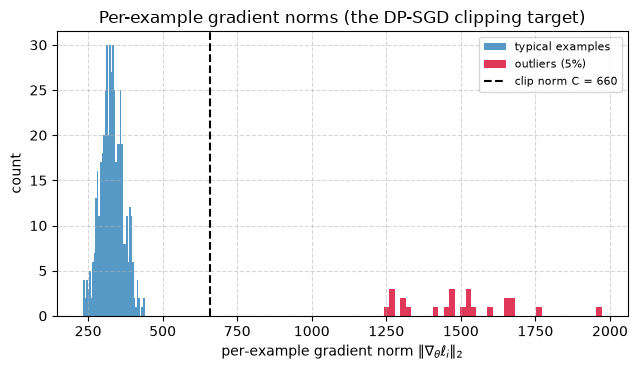

In [5]:
# per-example gradient norms -- the quantity DP-SGD clips
def global_norm(tree):
    return jnp.sqrt(sum(jnp.sum(g ** 2) for g in jax.tree.leaves(tree)))

per_ex_norms = jax.vmap(global_norm)(per_example_grad)

med = float(jnp.median(per_ex_norms))
C = 2.0 * med                            # a clipping norm at 2x the median
scale = jnp.minimum(1.0, C / (per_ex_norms + 1e-12))
clipped = jax.tree.map(lambda g: g * scale.reshape(-1, *([1] * (g.ndim - 1))), per_example_grad)
clipped_norms = jax.vmap(global_norm)(clipped)

print(f"per-example gradient norms:")
print(f"   min {per_ex_norms.min():>8.1f}   median {med:>8.1f}   "
      f"max {per_ex_norms.max():>8.1f}")
print(f"   max / median = {per_ex_norms.max() / med:.1f}x   "
      f"<- the worst example pulls this much harder than a typical one")
print(f"\nclipping at C = 2 x median = {C:.1f}:")
print(f"   max norm after clipping : {clipped_norms.max():.1f}  (bounded, by construction)")
print(f"   examples actually clipped: {float(jnp.mean(per_ex_norms > C)):.1%}")

# how much of the UNCLIPPED update comes from the few outliers?
share = float(jnp.sum(per_ex_norms[outlier_mask]) / jnp.sum(per_ex_norms))
print(f"\n{100 * float(jnp.mean(outlier_mask)):.0f}% of examples contribute "
      f"{100 * share:.0f}% of the total gradient norm  <- WITHOUT clipping.")

plt.figure(figsize=(6.5, 3.8))
plt.hist(np.asarray(per_ex_norms[~outlier_mask]), bins=40, alpha=0.75, label="typical examples")
plt.hist(np.asarray(per_ex_norms[outlier_mask]), bins=40, alpha=0.85, color="crimson",
         label="outliers (5%)")
plt.axvline(C, color="k", ls="--", label=f"clip norm C = {C:.0f}")
plt.xlabel("per-example gradient norm $\\|\\nabla_\\theta \\ell_i\\|_2$")
plt.ylabel("count")
plt.title("Per-example gradient norms (the DP-SGD clipping target)")
plt.legend(fontsize=8)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()

> **Observe:** the histogram is bimodal by construction, and that is the point. A 5%
> minority of examples produces gradients several times larger than everyone else's, and
> contributes a share of the total gradient norm far out of proportion to its count.
> Those examples are the *most memorizable* ones — an update dominated by a handful of
> examples is an update that carries information about those specific examples.
>
> That is *why* DP-SGD clips **before** averaging: bounding $\lVert \nabla_\theta \ell_i
> \rVert \leq C$ bounds how much any single example can move the parameters, which is the
> precondition for saying anything formal about privacy. Note the price, too: per-example
> gradients materialize $N$ copies of the parameter gradient, so this costs memory
> proportional to the batch size. Week 12 pays that bill and calibrates the noise. Today
> you have already written the mechanism — in one `vmap`.


### 🔬 Exercise 1

**Exercise:** `vmap` maps over *any* argument, not just data. Use it to build an
**ensemble**: `vmap` `predict_one` over a stack of 8 different parameter sets (`in_axes`
on `w` and `b`, `None` on `x`) and evaluate all 8 models on the same single input.

Then nest it: produce the full $(8, N, D_{\text{out}})$ tensor of every model's
prediction on every example with **two nested `vmap`s**, and verify the result against a
double Python loop on a small slice.


In [6]:
# --- Reference solution (instructor: blank this out for students) ---

E = 8                                                  # ensemble members
ke, kbe = jax.random.split(jax.random.key(11))
W_ens = jax.random.normal(ke, (E, D_OUT, D_IN)) / jnp.sqrt(D_IN)
B_ens = jax.random.normal(kbe, (E, D_OUT))

# (a) 8 models, one input: map over the PARAMETERS, share the data
ens_one = jax.vmap(predict_one, in_axes=(0, 0, None))(W_ens, B_ens, X[0])
print("8 models on 1 example :", ens_one.shape, "  <- in_axes=(0, 0, None)")

# (b) 8 models, N examples: nest vmap. Inner maps over data, outer over models.
per_model = jax.vmap(predict_one, in_axes=(None, None, 0))          # one model, all data
ens_all = jax.vmap(per_model, in_axes=(0, 0, None))(W_ens, B_ens, X)  # all models, all data
print("8 models on N examples:", ens_all.shape, "  <- (ensemble, batch, features)")

# (c) verify against a double Python loop on a small slice
ref = jnp.stack([jnp.stack([predict_one(W_ens[e], B_ens[e], X[i]) for i in range(4)])
                 for e in range(3)])
print("\nmatches double loop on [:3, :4]:", bool(jnp.allclose(ens_all[:3, :4], ref, atol=1e-5)))

# the ensemble mean and disagreement -- free, now that the axis exists
print(f"ensemble prediction std across members (mean): {float(jnp.mean(jnp.std(ens_all, axis=0))):.4f}")
print("\nNote the ordering: the LAST vmap applied is the OUTERMOST axis of the output.")

8 models on 1 example : (8, 64)   <- in_axes=(0, 0, None)
8 models on N examples: (8, 512, 64)   <- (ensemble, batch, features)



matches double loop on [:3, :4]: True
ensemble prediction std across members (mean): 0.7046

Note the ordering: the LAST vmap applied is the OUTERMOST axis of the output.


---

## 2. PyTrees: one data structure, one set of rules

Everything JAX transformations touch is a **PyTree**: a nested structure of containers
(tuples, lists, dicts, registered classes) whose leaves are arrays. `grad` returns a
PyTree shaped like its input. `optax` state is a PyTree. An Equinox model is a PyTree.
Your four Week 3 states are four PyTrees.

A PyTree is exactly two things:

| part | what it is | where it lives |
|------|-----------|----------------|
| **leaves** | the arrays — the actual data | traced, differentiated, sharded, sent over the wire |
| **treedef** | the structure + all static fields | compile-time constants; part of the `jit` cache key |

That second row is the one that generates errors. Two trees with the same leaves and
different treedefs are *different objects* to JAX, and the error message says
`Custom node type mismatch` or `List arity mismatch` rather than anything about your
model. Let us make both halves concrete.


In [7]:
tree = {"params": {"w": jnp.ones((2, 3)), "b": jnp.zeros(3)},
        "count": jnp.array(0),
        "name": "layer1"}                      # <- a string: NOT an array

leaves, treedef = jax.tree.flatten(tree)
print("leaves:")
for l in leaves:
    print("   ", type(l).__name__, getattr(l, "shape", l))
print("\ntreedef:", treedef)
print()
print("Note 'layer1' IS a leaf -- jax.tree.flatten does not know it is not an array.")
print("That is why eqx.filter / eqx.partition exist: they split array leaves from the rest.")

# tree.map applies elementwise over leaves, preserving structure
doubled = jax.tree.map(lambda x: x * 2 if eqx.is_array(x) else x, tree)
print("\ntree.map preserved the structure:", jax.tree.structure(doubled) == treedef)

leaves:
    ArrayImpl ()
    str layer1
    ArrayImpl (3,)
    ArrayImpl (2, 3)

treedef: PyTreeDef({'count': *, 'name': *, 'params': {'b': *, 'w': *}})

Note 'layer1' IS a leaf -- jax.tree.flatten does not know it is not an array.
That is why eqx.filter / eqx.partition exist: they split array leaves from the rest.



tree.map preserved the structure: True


### The treedef mismatch — the error you will actually hit

`tree.map` requires all trees to share a treedef. In Week 9 you will average parameter
trees coming back from clients, and the moment one client's tree differs — a list where
another has a tuple, a `None` where another has an array — you get this. Better to meet
it now, deliberately, than at 2 a.m. in a Flower simulation.


In [8]:
a = {"w": jnp.ones(3), "b": jnp.ones(2)}
b_ok = {"w": jnp.zeros(3), "b": jnp.zeros(2)}
b_bad = {"w": jnp.zeros(3), "bias": jnp.zeros(2)}      # renamed key -> different treedef
b_arity = {"w": jnp.zeros(3)}                          # missing key   -> different treedef

print("same structure  :", jax.tree.structure(a) == jax.tree.structure(b_ok))
print("renamed key     :", jax.tree.structure(a) == jax.tree.structure(b_bad))

avg = jax.tree.map(lambda x, y: (x + y) / 2, a, b_ok)
print("\naveraging matching trees works:", {k: v.tolist() for k, v in avg.items()})

for label, other in [("renamed key", b_bad), ("missing key", b_arity)]:
    try:
        jax.tree.map(lambda x, y: (x + y) / 2, a, other)
        print(f"{label}: no error?!")
    except ValueError as e:
        print(f"\n{label} -> ValueError:")
        print("   ", str(e).split(chr(10))[0][:110])

same structure  : True
renamed key     : False



averaging matching trees works: {'b': [0.5, 0.5], 'w': [0.5, 0.5, 0.5]}

renamed key -> ValueError:
    pytree structure error: different pytree metadata at key path

missing key -> ValueError:
    pytree structure error: different numbers of pytree children at key path


### Registering your own node

Any class can be a PyTree node if you tell JAX how to take it apart and put it back
together. This is what `eqx.Module` does for you. Doing it once by hand demystifies it —
and it forces the decision that matters: **which fields are data (leaves) and which are
structure (static)?**

Get that wrong in the static direction and you recompile on every value change. Get it
wrong in the data direction and JAX tries to differentiate your batch size.


In [9]:
@jax.tree_util.register_pytree_node_class
class TrainState:
    # Week 3's four states in one container -- with the right leaf/static split.
    def __init__(self, params, opt_state, bn_state, key, step_count):
        self.params = params           # leaf: arrays
        self.opt_state = opt_state     # leaf: arrays
        self.bn_state = bn_state       # leaf: arrays
        self.key = key                 # leaf: a key array
        self.step_count = step_count   # STATIC: a Python int

    def tree_flatten(self):
        children = (self.params, self.opt_state, self.bn_state, self.key)   # traced
        aux = (self.step_count,)                                            # static
        return children, aux

    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(*children, *aux)

    def __repr__(self):
        return f"TrainState(step_count={self.step_count}, ...)"


st = TrainState({"w": jnp.ones(3)}, {"mu": jnp.zeros(3)}, {"running_mean": jnp.zeros(3)},
                jax.random.key(0), step_count=0)

print("leaves        :", [getattr(l, 'shape', l) for l in jax.tree.leaves(st)])
print("treedef       :", jax.tree.structure(st))
print()
# tree.map works on it because it is a real node now
is_key = lambda x: jax.dtypes.issubdtype(x.dtype, jax.dtypes.prng_key)
st2 = jax.tree.map(lambda x: x if is_key(x) else x + 1, st)
print("tree.map over TrainState ->", st2, "params:", st2.params)
print()
print("step_count landed in the TREEDEF, so it is a compile-time constant:")
print("   step_count=0 ->", jax.tree.structure(TrainState({"w": jnp.ones(3)}, {}, {}, jax.random.key(0), 0)))
print("   step_count=1 ->", jax.tree.structure(TrainState({"w": jnp.ones(3)}, {}, {}, jax.random.key(0), 1)))
print("   ^ DIFFERENT treedefs -> different jit cache keys -> a recompile EVERY step.")
print("   Section 5 shows the damage. (Fix: make step_count a jnp array leaf.)")

leaves        : [(3,), (3,), (3,), ()]
treedef       : PyTreeDef(CustomNode(TrainState[(0,)], [{'w': *}, {'mu': *}, {'running_mean': *}, *]))



tree.map over TrainState -> TrainState(step_count=0, ...) params: {'w': Array([2., 2., 2.], dtype=float32)}

step_count landed in the TREEDEF, so it is a compile-time constant:
   step_count=0 -> PyTreeDef(CustomNode(TrainState[(0,)], [{'w': *}, {}, {}, *]))
   step_count=1 -> PyTreeDef(CustomNode(TrainState[(1,)], [{'w': *}, {}, {}, *]))
   ^ DIFFERENT treedefs -> different jit cache keys -> a recompile EVERY step.
   Section 5 shows the damage. (Fix: make step_count a jnp array leaf.)


> **Observe:** we just built the classic bug on purpose. Putting a step counter in the
> static half means every training step presents a new treedef, so `jit` recompiles the
> step function *every step* — a loop that gets slower the longer it runs, with no error
> and nothing in the code that looks wrong. The rule: **static = things that change a
> handful of times over the program's life** (layer sizes, flags). Anything that changes
> per step is a leaf, even if it is "just an integer".


### `ravel_pytree`: a PyTree is also a vector

One more PyTree tool, because Week 10 needs it. `jax.flatten_util.ravel_pytree` flattens
an entire tree into a **single 1-D vector** and hands back the function that puts it
back. That is the natural interface for anything that treats the model as a point in
$\mathbb{R}^d$: gradient compression, quantization, top-$k$ sparsification, norm-based
Byzantine filters (Week 13), and every "how many bytes does a client upload?" question.


In [10]:
from jax.flatten_util import ravel_pytree

# A stand-in for one client's model UPDATE. Real gradients/updates are heavy-tailed:
# a few coordinates are large, most are small. Student-t (df=3) mimics that; all-ones
# would not, and top-k would have nothing to find (see the uniform row below).
shapes = {"conv": {"w": (16, 3, 3, 3), "b": (16,)}, "head": {"w": (4, 16), "b": (4,)}}
leaves, treedef = jax.tree.flatten(shapes, is_leaf=lambda x: isinstance(x, tuple))
keys = jax.random.split(jax.random.key(7), len(leaves))
update_tree = jax.tree.unflatten(
    treedef, [0.01 * jax.random.t(k, 3.0, s) for k, s in zip(keys, leaves)])

flat, unravel = ravel_pytree(update_tree)
print("flat vector:", flat.shape, flat.dtype)
print(f"upload size: {flat.nbytes / 1024:.1f} KiB at float32")
print(f"             {flat.nbytes / 4 / 1024:.1f} KiB at int8 (Week 10's quantization)")

# round-trips exactly -- every leaf, not just one
back = unravel(flat)
exact = all(bool(jnp.all(x == y)) for x, y in zip(jax.tree.leaves(back), jax.tree.leaves(update_tree)))
print("\nround-trip exact (all leaves):", exact)

# top-k sparsification in two lines, because the tree is a vector
def topk_energy(v, frac=0.10):
    k = int(v.size * frac)
    idx = jnp.argsort(jnp.abs(v))[-k:]
    sparse = jnp.zeros_like(v).at[idx].set(v[idx])
    return k, float(jnp.sum(sparse ** 2) / jnp.sum(v ** 2))

k, kept_t = topk_energy(flat)
_, kept_g = topk_energy(jax.random.normal(jax.random.key(8), flat.shape))
_, kept_u = topk_energy(jnp.ones_like(flat))

print(f"\nkeep top-{k} of {flat.size} coords ({100 * k / flat.size:.0f}%) -> fraction of squared norm kept:")
print(f"   heavy-tailed (Student-t, df=3) : {100 * kept_t:>5.1f}%   <- closer to real updates")
print(f"   Gaussian                       : {100 * kept_g:>5.1f}%")
print(f"   uniform (all equal)            : {100 * kept_u:>5.1f}%   <- top-k buys nothing")

flat vector: (516,) float32
upload size: 2.0 KiB at float32
             0.5 KiB at int8 (Week 10's quantization)



round-trip exact (all leaves): True



keep top-51 of 516 coords (10%) -> fraction of squared norm kept:
   heavy-tailed (Student-t, df=3) :  61.8%   <- closer to real updates
   Gaussian                       :  45.3%
   uniform (all equal)            :   9.9%   <- top-k buys nothing


> **Observe:** the same 10% budget keeps very different amounts of signal depending on the
> *shape* of the distribution, not its size. With all coordinates equal, top-$k$ keeps
> exactly $k/d$ of the energy ($51/516 \approx 10\%$) — it is no better than random dropping.
> With Gaussian coordinates it keeps about 45%, matching the theoretical ~44% for the top
> decile of a normal. With heavy tails most of the energy survives, because most of it
> lived in a few coordinates to begin with. That concentration is an *empirical* property
> of real gradients, not a theorem, and it is the whole reason top-$k$ works in Week 10.
> (Real top-$k$ also keeps the dropped residual locally and adds it back next round —
> *error feedback* — or the dropped mass is lost for good.)


---

## 3. PRNG: randomness is data you thread

NumPy's `np.random.normal()` reads and mutates a hidden global. That is a side effect,
and a JAX transformation cannot see it, cache it, replay it, or split it across devices.
So JAX makes randomness explicit: a **key** is an array, you pass it in, and you get
different numbers only if you pass a different key.

The consequence trips up everyone once: **the same key always gives the same numbers.**
That is a feature — it is what makes an experiment reproducible and a `vmap` over clients
well-defined — but it means reusing a key silently correlates your randomness. Nothing
raises. Your dropout mask is just the same mask every step.

Two operations produce new keys:

| operation | signature | use it when |
|-----------|-----------|-------------|
| `jax.random.split(key, n)` | key → $n$ new keys | you need $n$ streams *now* and can thread the result |
| `jax.random.fold_in(key, i)` | key, int → one key | you can name the consumer: step $i$, client $i$, layer $i$ |

`fold_in` is the one that scales to federated learning. Fifty clients do not need to
receive their keys from a central `split` and mail them back; each derives its own from
`fold_in(round_key, client_id)`. Independent, reproducible, no coordination.


In [11]:
k = jax.random.key(0)

print("a key is an array:", k.shape, k.dtype)
print()
# THE BUG: reusing a key
bad1 = jax.random.normal(k, (3,))
bad2 = jax.random.normal(k, (3,))        # same key -> same numbers, no warning
print("reused key, draw 1:", np.asarray(bad1).round(4))
print("reused key, draw 2:", np.asarray(bad2).round(4))
print("identical:", bool(jnp.all(bad1 == bad2)), "  <- silent. no error, no warning.")
print()
# THE FIX: split, and never reuse the parent
k, sub1 = jax.random.split(k)
good1 = jax.random.normal(sub1, (3,))
k, sub2 = jax.random.split(k)
good2 = jax.random.normal(sub2, (3,))
print("split, draw 1:", np.asarray(good1).round(4))
print("split, draw 2:", np.asarray(good2).round(4))
print("identical:", bool(jnp.all(good1 == good2)))

a key is an array: () key<fry>

reused key, draw 1: [ 1.6226  2.0253 -0.4336]
reused key, draw 2: [ 1.6226  2.0253 -0.4336]
identical: True   <- silent. no error, no warning.

split, draw 1: [-2.4425 -2.0357  0.2055]
split, draw 2: [-1.2575 -0.4016 -1.1214]
identical: False


### Are the streams actually independent?

"They look different" is not a claim, it is an impression. Let us measure. 


We generate n values from each of S=8 random streams. Then, among every pair of streams, we find the largest correlation.

With 8 streams, there are

$$
\binom{8}{2}=28
$$

different pairs. If the streams are independent, the correlation of one pair usually varies by about

$$
 1 \over \sqrt{n}.
$$
However, we are choosing the largest correlation from 28 pairs. Therefore, we should expect the maximum to be a few times larger than 1/√(n). The largest of many noisy values is usually larger than a typical value. A test that ignores this may incorrectly say that good independent streams are not random.

We will compare the key-generation methods shown in the table above. We will also test a method commonly used with NumPy: increasing the seed by one for each stream.

Before comparing the results, however, we must first confirm that the generated streams are actually different. This check is more important than it may seem


In [12]:
n = 4000
S = 8

split_keys   = jax.random.split(jax.random.key(0), S)
foldin_keys  = jnp.stack([jax.random.fold_in(jax.random.key(0), i) for i in range(S)])
seed_keys    = jnp.stack([jax.random.key(i) for i in range(S)])     # the "incrementing seed" habit

def streams(keys):
    return jax.vmap(lambda kk: jax.random.normal(kk, (n,)))(keys)   # vmap OVER KEYS

def max_offdiag_corr(x):
    c = np.corrcoef(np.asarray(x))
    return float(np.max(np.abs(c - np.eye(len(c)))))

# Sanity check FIRST: are split and fold_in even producing different keys?
same = bool(jnp.all(jax.random.key_data(split_keys) == jax.random.key_data(foldin_keys)))
print(f"split(k, {S})[i] == fold_in(k, i) for every i: {same}"
      f"   (jax_threefry_partitionable = {jax.config.jax_threefry_partitionable})")
print("-> in current JAX they are the SAME keys, so they get one row below, not two.\n")

noise_floor = 1.0 / np.sqrt(n)
print(f"{'key derivation':>18}  {'max |cross-corr|':>17}  {'vs 1/sqrt(n)':>14}")
print("-" * 55)
for name, keys in [("split / fold_in", split_keys), ("seed = 0,1,2...", seed_keys)]:
    m = max_offdiag_corr(streams(keys))
    print(f"{name:>18}  {m:>17.4f}  {m / noise_floor:>13.2f}x")
print(f"\n1/sqrt(n) = {noise_floor:.4f} for n = {n} samples, and we took the max over "
      f"{8 * 7 // 2} pairs,")
print("so ~2-3x the noise floor is exactly what independent streams should produce.")
print()
print("Both PASS -- including the incrementing seed. JAX's PRNG is COUNTER-BASED:")
print("it hashes (seed, counter), so seeds 0 and 1 give unrelated streams. (Try this")
print("with a legacy stateful RNG and adjacent seeds and you may not be so lucky.)")
print()
print("So the case for split/fold_in is NOT statistical -- it is structural:")
print("they compose and they document the intent. Reusing a key is the bug; how you")
print("DERIVE distinct keys is a design choice -- with one catch, next.")

split(k, 8)[i] == fold_in(k, i) for every i: True   (jax_threefry_partitionable = True)
-> in current JAX they are the SAME keys, so they get one row below, not two.

    key derivation   max |cross-corr|    vs 1/sqrt(n)
-------------------------------------------------------
   split / fold_in             0.0345           2.18x
   seed = 0,1,2...             0.0434           2.74x

1/sqrt(n) = 0.0158 for n = 4000 samples, and we took the max over 28 pairs,
so ~2-3x the noise floor is exactly what independent streams should produce.

Both PASS -- including the incrementing seed. JAX's PRNG is COUNTER-BASED:
it hashes (seed, counter), so seeds 0 and 1 give unrelated streams. (Try this
with a legacy stateful RNG and adjacent seeds and you may not be so lucky.)

So the case for split/fold_in is NOT statistical -- it is structural:
they compose and they document the intent. Reusing a key is the bug; how you
DERIVE distinct keys is a design choice -- with one catch, next.


### The catch: `split` and `fold_in` on the same parent collide

Because `split(k, n)[i]` *is* `fold_in(k, i)`, using **both** on one parent key hands two
consumers the same stream. This is exactly the shape of a federated round: the server
`split`s the round key for its own needs (client sampling, dropout, ...), and the clients
`fold_in` their id into the same round key. Nothing raises.


In [10]:
round_key = jax.random.key(42)

def draw(k):
    return float(jax.random.normal(k, ()))

# BUGGY: two consumers derive from the same parent, through different-looking APIs
server_keys = jax.random.split(round_key, 4)                        # server: 4 uses
client_keys = [jax.random.fold_in(round_key, c) for c in range(4)]  # clients 0..3

print("buggy -- one parent, both APIs:")
for i in range(4):
    print(f"   server key {i}: {draw(server_keys[i]):>8.4f}    client {i}: {draw(client_keys[i]):>8.4f}")
print("   -> every client draws exactly the server's random numbers. Silently.\n")

# FIXED: give each consumer its own child of the parent, then derive inside it
k_server, k_clients = jax.random.split(round_key)
server_keys = jax.random.split(k_server, 4)
client_keys = [jax.random.fold_in(k_clients, c) for c in range(4)]
all_keys = jnp.stack([*server_keys, *client_keys])
n_distinct = len({tuple(np.asarray(r).tolist()) for r in jax.random.key_data(all_keys)})

print(f"fixed -- one child per consumer: {n_distinct} distinct keys out of {len(all_keys)}")
for i in range(4):
    print(f"   server key {i}: {draw(server_keys[i]):>8.4f}    client {i}: {draw(client_keys[i]):>8.4f}")

buggy -- one parent, both APIs:
   server key 0:   0.0759    client 0:   0.0759
   server key 1:   0.6058    client 1:   0.6058
   server key 2:   0.4323    client 2:   0.4323
   server key 3:  -0.2819    client 3:  -0.2819
   -> every client draws exactly the server's random numbers. Silently.

fixed -- one child per consumer: 8 distinct keys out of 8
   server key 0:  -0.7198    client 0:  -0.7441
   server key 1:  -0.2109    client 1:  -1.0413
   server key 2:  -1.8260    client 2:   0.9770
   server key 3:  -1.0296    client 3:   0.3787


> **Observe:** the buggy version prints two identical columns — the "independent"
> clients are replaying the server's randomness. The statistical test above could never
> catch this, because each stream on its own is perfectly good randomness; the bug is that
> two consumers hold the *same* stream. The rule: **one parent key, one derivation
> scheme.** If a key has several consumers, `split` it into one child per consumer first,
> then `split` or `fold_in` inside each child. (The equality itself is an implementation
> detail of the current `jax_threefry_partitionable` default — which is exactly why your
> code's correctness should not depend on whether it holds.)


### `fold_in` and the shape of Week 9

Here is the pattern the federated labs use. The server holds one key per round. Each
client derives its own key from `(round, client_id)`. No client needs to talk to another,
every client's stream is independent, the whole thing is reproducible from a single seed,
and it works identically whether the clients run in one process or fifty machines.


In [14]:
def client_key(master, rnd, cid):
    # fold_in twice: once for the round, once for the client. Order is a convention;
    # what matters is that (round, client) -> a distinct, reproducible stream.
    return jax.random.fold_in(jax.random.fold_in(master, rnd), cid)


master = jax.random.key(2024)
N_CLIENTS, N_ROUNDS = 5, 3

print("first random draw per (round, client):")
print(f"{'':>8}" + "".join(f"{'client ' + str(c):>12}" for c in range(N_CLIENTS)))
for r in range(N_ROUNDS):
    row = "".join(f"{float(jax.random.normal(client_key(master, r, c), ())):>12.4f}"
                  for c in range(N_CLIENTS))
    print(f"round {r} " + row)

print("\nreproducible: client 3, round 1 recomputed from the master seed alone ->",
      f"{float(jax.random.normal(client_key(master, 1, 3), ())):.4f}")
print("no coordination, no state shipped, no collisions. This is Week 9's PRNG design.")

first random draw per (round, client):
            client 0    client 1    client 2    client 3    client 4
round 0       0.7573      0.1176      1.3024      0.6763     -0.4431
round 1       0.3164     -1.6899     -0.3943     -0.2007      1.2270
round 2       0.0226     -1.6893     -0.0385     -1.2257      0.3730

reproducible: client 3, round 1 recomputed from the master seed alone -> -0.2007
no coordination, no state shipped, no collisions. This is Week 9's PRNG design.


> **Observe:** every entry differs, and any one of them is recoverable from the master
> seed plus two integers. Contrast with the alternative you might reach for — giving each
> client `jax.random.key(client_id)` and reusing it every round. That client would draw
> **the same dropout masks and the same shuffle in every round**, forever. It would still
> train. It would just quietly be a worse experiment, and nothing would tell you.


### 🔬 Exercise 2

**Exercise:** below is a jitted dropout layer with the key-reuse bug: it takes a key
*once* and uses it for every call. Show the bug empirically (the mask is identical across
calls), then fix it by threading the key. Confirm that (a) the masks now differ, (b) the
expected value of the output is preserved by the $1/(1-p)$ scaling, and (c) the fixed
version is still deterministic given the same starting key.


In [15]:
# --- Reference solution (instructor: blank this out for students) ---

@jax.jit
def dropout_buggy(x, k, p=0.5):
    mask = jax.random.bernoulli(k, 1 - p, x.shape)
    return jnp.where(mask, x / (1 - p), 0.0)

@jax.jit
def dropout_fixed(x, k, p=0.5):
    k_use, k_next = jax.random.split(k)              # consume one, return the other
    mask = jax.random.bernoulli(k_use, 1 - p, x.shape)
    return jnp.where(mask, x / (1 - p), 0.0), k_next


x = jnp.ones((8,))
kk = jax.random.key(5)

# (a) the bug
m1 = dropout_buggy(x, kk)
m2 = dropout_buggy(x, kk)
print("buggy call 1:", np.asarray(m1))
print("buggy call 2:", np.asarray(m2))
print("identical masks:", bool(jnp.all(m1 == m2)), " <- the same 'random' mask every step")

# the fix
print()
k_cur = jax.random.key(5)
outs = []
for i in range(3):
    out, k_cur = dropout_fixed(x, k_cur)
    outs.append(np.asarray(out))
    print(f"fixed call {i}:", outs[-1])
print("all distinct:", not (np.array_equal(outs[0], outs[1]) or np.array_equal(outs[1], outs[2])))

# (b) unbiasedness of the 1/(1-p) scaling
k_cur = jax.random.key(5)
big = jnp.ones((20000,))
acc = []
for _ in range(20):
    out, k_cur = dropout_fixed(big, k_cur)
    acc.append(float(jnp.mean(out)))
print(f"\nE[dropout(1)] over 20 draws = {np.mean(acc):.4f}  (should be ~1.0: the scaling is unbiased)")

# (c) determinism given the same start
def run(seed, steps=3):
    k_ = jax.random.key(seed)
    o = None
    for _ in range(steps):
        o, k_ = dropout_fixed(x, k_)
    return o
print("same seed -> same trajectory:", bool(jnp.all(run(5) == run(5))))
print("different seed -> different :", not bool(jnp.all(run(5) == run(6))))

buggy call 1: [2. 0. 0. 2. 0. 0. 2. 2.]
buggy call 2: [2. 0. 0. 2. 0. 0. 2. 2.]
identical masks: True  <- the same 'random' mask every step



fixed call 0: [0. 0. 2. 0. 0. 0. 2. 2.]
fixed call 1: [0. 2. 0. 2. 0. 2. 2. 0.]
fixed call 2: [2. 0. 2. 2. 2. 2. 0. 0.]
all distinct: True



E[dropout(1)] over 20 draws = 0.9995  (should be ~1.0: the scaling is unbiased)
same seed -> same trajectory: True
different seed -> different : True


---

## 4. `scan`: give the loop to the compiler

A Python `for` loop inside a traced function does not become a loop. It gets **unrolled**:
tracing executes the Python, so the trace contains one copy of the body per iteration.
Twenty steps, twenty copies. Two hundred steps, two hundred copies, and an XLA program
so large that compiling it takes longer than running it.

`jax.lax.scan` is the loop as a **primitive**. Its body is traced once, and the loop
structure survives into the compiled program:

```
scan(f, init, xs) :   carry = init
                      for x in xs:               # <- stays a loop in the IR
                          carry, y = f(carry, x)
                      return carry, stack(ys)
```

The rules that come with it are the rules of a compiled loop: the carry's **shape and
dtype must be identical** on every iteration (it is the loop's register file), the trip
count is fixed at compile time, and the body cannot branch on a traced value with Python
`if`.

The payoff is compile time. Let us measure it, because a factor you can plot is worth ten
paragraphs of assertion.


In [16]:
def mlp_step(carry, x):
    # a toy "training step": carry is the parameter vector, x is a batch
    w = carry
    g = jnp.mean(x, axis=0) * jnp.tanh(w) + 0.01 * w
    return w - 0.1 * g, jnp.sum(g ** 2)


def unrolled(w, xs, T):
    ys = []
    for t in range(T):              # Python loop: traced T times, unrolled T times
        w, y = mlp_step(w, xs[t])
        ys.append(y)
    return w, jnp.stack(ys)


def scanned(w, xs):
    return jax.lax.scan(mlp_step, w, xs)     # traced ONCE


DIM = 256
w0 = jnp.ones(DIM)

Ts = [2, 4, 8, 16, 32, 64, 128]
compile_unroll, compile_scan, run_unroll, run_scan = [], [], [], []

print(f"{'T':>5}  {'compile unroll (s)':>18}  {'compile scan (s)':>17}  {'run unroll (ms)':>16}  {'run scan (ms)':>14}")
print("-" * 82)
for T in Ts:
    xs = jax.random.normal(jax.random.key(T), (T, 16, DIM))

    f_un = jax.jit(functools.partial(unrolled, T=T))
    t0 = time.perf_counter(); jax.block_until_ready(f_un(w0, xs)); c_un = time.perf_counter() - t0

    f_sc = jax.jit(scanned)
    t0 = time.perf_counter(); jax.block_until_ready(f_sc(w0, xs)); c_sc = time.perf_counter() - t0

    r_un = bench(f_un, w0, xs)
    r_sc = bench(f_sc, w0, xs)

    # correctness first: the two must agree
    assert jnp.allclose(f_un(w0, xs)[0], f_sc(w0, xs)[0], atol=1e-5)

    compile_unroll.append(c_un); compile_scan.append(c_sc)
    run_unroll.append(r_un); run_scan.append(r_sc)
    print(f"{T:>5}  {c_un:>18.3f}  {c_sc:>17.3f}  {r_un * 1e3:>16.3f}  {r_sc * 1e3:>14.3f}")

print("\n(compile times include the first call; the two versions compute the same thing")
print(" -- asserted above -- so any difference is pure compilation strategy.)")

    T  compile unroll (s)   compile scan (s)   run unroll (ms)   run scan (ms)
----------------------------------------------------------------------------------


    2               0.057              0.058             0.025           0.024


    4               0.068              0.059             0.040           0.030


    8               0.110              0.060             0.057           0.040


   16               0.215              0.056             0.116           0.056


   32               0.546              0.057             0.253           0.090


   64               2.298              0.062             0.866           0.148


  128              13.412              0.071             4.128           0.249

(compile times include the first call; the two versions compute the same thing
 -- asserted above -- so any difference is pure compilation strategy.)


compile time, unrolled: 0.057s at T=2  ->  13.412s at T=128   (236.3x)
compile time, scan    : 0.058s at T=2  ->  0.071s at T=128   (1.2x)

run time ratio (unroll/scan) at T=128: 16.61x


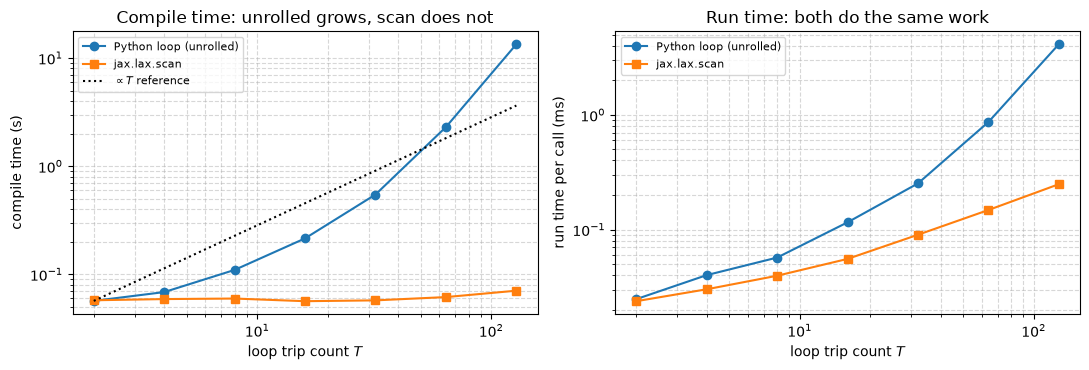

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].loglog(Ts, compile_unroll, "o-", label="Python loop (unrolled)")
ax[0].loglog(Ts, compile_scan, "s-", label="jax.lax.scan")
ref = np.array(compile_unroll[0]) * np.array(Ts) / Ts[0]
ax[0].loglog(Ts, ref, "k:", label="$\\propto T$ reference")
ax[0].set_xlabel("loop trip count $T$")
ax[0].set_ylabel("compile time (s)")
ax[0].set_title("Compile time: unrolled grows, scan does not")
ax[0].legend(fontsize=8)
ax[0].grid(True, ls="--", alpha=0.5, which="both")

ax[1].loglog(Ts, np.array(run_unroll) * 1e3, "o-", label="Python loop (unrolled)")
ax[1].loglog(Ts, np.array(run_scan) * 1e3, "s-", label="jax.lax.scan")
ax[1].set_xlabel("loop trip count $T$")
ax[1].set_ylabel("run time per call (ms)")
ax[1].set_title("Run time: both do the same work")
ax[1].legend(fontsize=8)
ax[1].grid(True, ls="--", alpha=0.5, which="both")

plt.tight_layout()

print(f"compile time, unrolled: {compile_unroll[0]:.3f}s at T={Ts[0]}  ->  "
      f"{compile_unroll[-1]:.3f}s at T={Ts[-1]}   ({compile_unroll[-1] / compile_unroll[0]:.1f}x)")
print(f"compile time, scan    : {compile_scan[0]:.3f}s at T={Ts[0]}  ->  "
      f"{compile_scan[-1]:.3f}s at T={Ts[-1]}   ({compile_scan[-1] / compile_scan[0]:.1f}x)")
print(f"\nrun time ratio (unroll/scan) at T={Ts[-1]}: {run_unroll[-1] / run_scan[-1]:.2f}x")

> **Observe:** the compile-time curves separate exactly as predicted. The unrolled loop
> tracks the $\propto T$ reference — 64× the trip count, roughly 64× the tracing and
> compilation work, because the XLA program literally contains $T$ copies of the body.
> `scan`'s compile time is essentially **flat**: one body, one compile, whatever $T$ is.
>
> The run times are close, and that is the honest reading — `scan` is not faster at
> *running*, it is cheaper to *compile*. (At small $T$ the unrolled version can even edge
> ahead: XLA can fuse across iterations when it can see them all, which `scan` forbids.
> That is the real trade-off, and it is why unrolling a short inner loop is sometimes
> right.) The reason `scan` matters for us is Week 7: a Local SGD experiment sweeping
> $\tau \in \{1, 5, 20, 100\}$ local steps means four *different trip counts*. Unrolled,
> that is four compiles that grow with $\tau$. Scanned, it is one compiled program per
> shape, and $\tau$ is just the length of `xs`.


### 🔬 Exercise 3

**Exercise:** `scan`'s carry must be shape- and dtype-stable. Break that rule three ways
and read each error, because you will meet all three:

1. carry a Python `int` and add `1` to it each iteration (dtype instability: `int` →
   weak-typed `int32` → ...),
2. return a carry with a different **shape** than the input carry,
3. accumulate into a growing list inside the body.

Then write the *correct* version of (3): use `scan`'s second output (`ys`) to stack a
per-iteration value, which is what it is for.


In [18]:
# --- Reference solution (instructor: blank this out for students) ---

xs = jnp.arange(5.0)

# (1) dtype instability in the carry
def body_int(carry, x):
    return carry + 1, x            # carry: Python int -> weak int32 -> ...
try:
    out = jax.lax.scan(body_int, 0, xs)
    print("(1) Python int carry: no error. carry ->", out[0], type(out[0]))
    print("    (it works, but the int was promoted to a traced array on iteration 1;")
    print("     the failure appears when the promotion CHANGES dtype -- see below.)")
except TypeError as e:
    print("(1) TypeError:", str(e).split(chr(10))[0][:100])

def body_promote(carry, x):
    return carry + x, x            # int32 carry + float32 x -> float32 carry: dtype CHANGED
try:
    jax.lax.scan(body_promote, jnp.int32(0), xs)     # a STRONGLY typed int32 carry
    print("(1b) promoted carry: no error?!")
except TypeError as e:
    print("(1b) strongly-typed int32 carry + float32 xs -> TypeError:")
    print("    ", str(e).split(chr(10))[0][:100])
    print("     ^ THIS is the dtype-stability rule biting. In (1) the Python int was")
    print("       weakly typed, so JAX was free to pick int32 and stay there.")

# (2) shape instability
def body_grow(carry, x):
    return jnp.concatenate([carry, x[None]]), x     # carry grows every iteration
try:
    jax.lax.scan(body_grow, jnp.zeros(1), xs)
    print("\n(2) growing carry: no error?!")
except (TypeError, ValueError) as e:
    print("\n(2) growing carry -> " + type(e).__name__ + ":")
    print("    ", str(e).split(chr(10))[0][:100])

# (3) a Python list inside the body
def body_list(carry, x):
    carry.append(x)                # a Python side effect during tracing
    return carry, x
try:
    jax.lax.scan(body_list, [], xs)
    print("\n(3) list carry: no error?!")
except (TypeError, ValueError) as e:
    print("\n(3) appending to a list carry -> " + type(e).__name__ + ":")
    print("    ", str(e).split(chr(10))[0][:100])

# (3, done right): that is what ys is for
def body_right(carry, x):
    new = carry + x
    return new, new                # (carry, y) -- y gets stacked for you
final, ys = jax.lax.scan(body_right, 0.0, xs)
print("\n(3 correct) running sum via ys:", np.asarray(ys), " final carry:", float(final))
print("            ^ no list, no append: scan stacks the per-iteration outputs.")

(1) Python int carry: no error. carry -> 5 <class 'jaxlib._jax.ArrayImpl'>
    (it works, but the int was promoted to a traced array on iteration 1;
     the failure appears when the promotion CHANGES dtype -- see below.)
(1b) strongly-typed int32 carry + float32 xs -> TypeError:
     scan body function carry input and carry output must have equal types, but they differ:
     ^ THIS is the dtype-stability rule biting. In (1) the Python int was
       weakly typed, so JAX was free to pick int32 and stay there.

(2) growing carry -> TypeError:
     scan body function carry input and carry output must have equal types, but they differ:

(3) appending to a list carry -> TypeError:
     scan body function carry input and carry output must have the same pytree structure, but they differ

(3 correct) running sum via ys: [ 0.  1.  3.  6. 10.]  final carry: 10.0
            ^ no list, no append: scan stacks the per-iteration outputs.


---

## 5. The recompilation traps

`jit` caches compiled code keyed by the **structure** of the call: the treedef of every
argument, and the shape and dtype of every array leaf. Change the key and you get a new
compile, silently, at full cost. Change something the key does *not* cover and you get
the **old code**, silently, at full wrongness.

That second failure is the one worth fearing. Here is the taxonomy:

| you change | recompile? | why |
|-----------|------------|-----|
| array **shape** (batch 64 → 65) | **yes** | shape is part of the cache key |
| array **dtype** (f32 → f64/bf16) | **yes** | dtype is part of the cache key |
| array **value** | no | values are traced — this is the whole point |
| a Python scalar **argument** | no | passed as a weakly-typed traced value |
| a `static_argnums` **argument** | **yes** | its value *is* the cache key |
| the **treedef** (dict key, list arity, Equinox static field) | **yes** | structure is the cache key |
| a Python scalar **captured in a closure** | **no — and this is the bug** | it was baked in at trace time |

`jax.jit` exposes `_cache_size()`, so we do not have to guess. Let us walk the table.


In [19]:
@jax.jit
def f(x, c):
    return jnp.sum(x * c)


def probe(label, *args):
    before = f._cache_size()
    jax.block_until_ready(f(*args))
    after = f._cache_size()
    tag = "RECOMPILED" if after > before else "cache hit"
    print(f"{label:>38}  cache: {before} -> {after}   {tag}")


f._clear_cache() if hasattr(f, "_clear_cache") else None
print(f"{'call':>38}  {'cache size':>14}")
print("-" * 68)
probe("f(ones(8), 2.0)               first", jnp.ones(8), 2.0)
probe("f(ones(8), 2.0)               again", jnp.ones(8), 2.0)
probe("f(ones(8), 3.0)      value changed", jnp.ones(8), 3.0)
probe("f(zeros(8), 2.0)     data changed", jnp.zeros(8), 2.0)
probe("f(ones(9), 2.0)      SHAPE changed", jnp.ones(9), 2.0)
probe("f(ones(8, dtype=int32), 2.0)      ", jnp.ones(8, dtype=jnp.int32), 2.0)
print()
print(f"final cache size: {f._cache_size()} entries")
print("shape and dtype each bought a new entry. Values -- of the array OR of the")
print("Python scalar argument -- did not. Scalar args are traced, not baked.")

                                  call      cache size
--------------------------------------------------------------------
   f(ones(8), 2.0)               first  cache: 0 -> 1   RECOMPILED
   f(ones(8), 2.0)               again  cache: 1 -> 1   cache hit
    f(ones(8), 3.0)      value changed  cache: 1 -> 1   cache hit
     f(zeros(8), 2.0)     data changed  cache: 1 -> 1   cache hit
    f(ones(9), 2.0)      SHAPE changed  cache: 1 -> 2   RECOMPILED
    f(ones(8, dtype=int32), 2.0)        cache: 2 -> 3   RECOMPILED

final cache size: 3 entries
shape and dtype each bought a new entry. Values -- of the array OR of the
Python scalar argument -- did not. Scalar args are traced, not baked.


### Trap A: `static_argnums` — the cache key you chose

Sometimes a value *must* be static: you cannot use a traced value as a shape, or branch
on it with Python `if`. `static_argnums` makes JAX treat the argument as a compile-time
constant. The cost is exactly what you would expect and exactly what people forget: **one
compile per distinct value**.


In [20]:
def needs_python_branch(x, mode):
    if mode == "sum":            # a Python if on `mode` -- only legal if mode is static
        return jnp.sum(x)
    return jnp.max(x)


# Without static: mode is traced, and `if` on a tracer raises.
try:
    jax.jit(needs_python_branch)(jnp.ones(4), "sum")
except Exception as e:
    print(type(e).__name__, "->", str(e).split(chr(10))[0][:95])

print()
g = jax.jit(needs_python_branch, static_argnums=1)
for mode in ["sum", "max", "sum", "max"]:
    before = g._cache_size()
    jax.block_until_ready(g(jnp.ones(4), mode))
    print(f"  g(x, {mode!r:>6})  cache: {before} -> {g._cache_size()}")
print("\ntwo distinct values -> two compiles, then hits. Fine for 2 modes.")

# The failure: a static arg that varies a lot
h = jax.jit(lambda x, n: x * n, static_argnums=1)
for n in range(6):
    jax.block_until_ready(h(jnp.ones(4), n))
print(f"\nh(x, n) with n static, n = 0..5  ->  cache size {h._cache_size()} "
      f"<- SIX compiles for one function")
print("The lesson for Week 9: batch size, client id, or local step count as a static")
print("argument means one compile per client. 100 clients, 100 compiles, and the")
print("simulation spends its life in XLA instead of in your algorithm.")

TypeError -> Error interpreting argument to <function needs_python_branch at 0x365e2d6c0> as an abstract arr



  g(x,  'sum')  cache: 0 -> 1
  g(x,  'max')  cache: 1 -> 2
  g(x,  'sum')  cache: 2 -> 2
  g(x,  'max')  cache: 2 -> 2

two distinct values -> two compiles, then hits. Fine for 2 modes.



h(x, n) with n static, n = 0..5  ->  cache size 6 <- SIX compiles for one function
The lesson for Week 9: batch size, client id, or local step count as a static
argument means one compile per client. 100 clients, 100 compiles, and the
simulation spends its life in XLA instead of in your algorithm.


### Trap B: the silent one

Everything above was *loud*: you paid a compile and could have noticed. This one costs
nothing and gives you the wrong answer.

A Python `float` referenced from an enclosing scope is not an argument. It is read
**once**, at trace time, and burned into the compiled code as a literal. Rebind the name
afterwards and JAX has no idea: the cache key did not change, so you get the old
executable — with the old constant inside it.


In [21]:
learning_rate = 0.1                # a Python float in the enclosing scope

@jax.jit
def step_closure(p, g):
    return p - learning_rate * g   # captured, NOT an argument

p0 = jnp.array([1.0])
g0 = jnp.array([1.0])

print("learning_rate = 0.1 -> step:", float(step_closure(p0, g0)[0]), " (expect 0.9)")

learning_rate = 0.5                # "change the learning rate"
print("learning_rate = 0.5 -> step:", float(step_closure(p0, g0)[0]), " (expect 0.5)")
print("cache size:", step_closure._cache_size(), "-> no recompile: 0.1 is a LITERAL in the code")
print()
print("\nthe smoking gun -- find the constant in the lowered program:")
hlo = step_closure.lower(p0, g0).as_text()
for line in hlo.split(chr(10)):
    if "constant" in line:
        print("   ", line.strip()[:80])
print("    ^ 1.0e-01 is a LITERAL baked into the code. It is not an input, so")
print("      rebinding the Python name cannot possibly affect it.")
print()

# the fix: make it an argument
@jax.jit
def step_arg(p, g, lr):
    return p - lr * g

print("passed as an argument:")
print("  lr = 0.1 -> step:", float(step_arg(p0, g0, 0.1)[0]))
print("  lr = 0.5 -> step:", float(step_arg(p0, g0, 0.5)[0]))
print("  cache size:", step_arg._cache_size(), "-> ONE compile, both values correct.")

learning_rate = 0.1 -> step: 0.8999999761581421  (expect 0.9)
learning_rate = 0.5 -> step: 0.8999999761581421  (expect 0.5)
cache size: 1 -> no recompile: 0.1 is a LITERAL in the code


the smoking gun -- find the constant in the lowered program:
    %cst = stablehlo.constant dense<1.000000e-01> : tensor<f32>
    ^ 1.0e-01 is a LITERAL baked into the code. It is not an input, so
      rebinding the Python name cannot possibly affect it.

passed as an argument:


  lr = 0.1 -> step: 0.8999999761581421
  lr = 0.5 -> step: 0.5
  cache size: 1 -> ONE compile, both values correct.


> **Observe:** the second call printed `0.9` when the code plainly says the learning rate
> is `0.5`. No error, no warning, no recompile. The `0.1` was frozen into the executable
> at trace time — you can see it in the lowered HLO. This is the single most expensive JAX
> bug in a research codebase, because it produces *plausible* results: an LR sweep where
> every configuration mysteriously behaves like the first one you ran.
>
> The rule follows directly from the cache key: **if a value can change, it must be an
> argument.** Learning rates, clipping norms, noise multipliers, temperature, $\tau$ —
> every one of them is a hyperparameter you *will* sweep, and every one of them belongs
> in the signature. (Optax's schedules exist for exactly this reason: the schedule reads
> the step count from the optimizer *state*, which is an argument.)


### 🔬 Exercise 4

**Exercise:** the function below has a recompilation problem that a profiler will not
find for you: it is called in a loop over batches, and the **last batch is smaller**
because the dataset size is not divisible by the batch size. Demonstrate the extra
compile with `_cache_size()`, measure what it costs in wall-clock, and fix it two ways —
(a) drop the ragged last batch, (b) pad it to full size and mask the loss. State which
one you would use in Week 9's federated simulation, where clients have **unequal dataset
sizes** by definition.


In [22]:
# --- Reference solution (instructor: blank this out for students) ---

@jax.jit
def batch_loss(w, xb, yb):
    return jnp.mean((xb @ w - yb) ** 2)

@jax.jit
def batch_loss_masked(w, xb, yb, mask):
    per = (xb @ w - yb) ** 2
    return jnp.sum(per * mask) / jnp.sum(mask)      # mask, not slice: shape stays fixed


Dw = 32
w = jax.random.normal(jax.random.key(0), (Dw,))
n_data, bs = 1000, 128                              # 1000 = 7*128 + 104  <- ragged tail
Xd = jax.random.normal(jax.random.key(1), (n_data, Dw))
Yd = jax.random.normal(jax.random.key(2), (n_data,))

# (0) the problem -- FIRST pass over the data, so compiles are included (as in real life)
t0 = time.perf_counter()
for i in range(0, n_data, bs):
    jax.block_until_ready(batch_loss(w, Xd[i:i + bs], Yd[i:i + bs]))
t_ragged_cold = time.perf_counter() - t0
print(f"ragged, 1st epoch : {t_ragged_cold * 1e3:>7.1f} ms   cache = {batch_loss._cache_size()} entries")
print(f"   shapes seen: {[Xd[i:i+bs].shape[0] for i in range(0, n_data, bs)]}")
print("   ^ the 104-example tail is a DIFFERENT shape -> a SECOND compiled program.")

# steady state: once both shapes are compiled, the ragged tail costs nothing extra
def timed_epoch(fn, args_for):
    t0 = time.perf_counter()
    for a in args_for:
        jax.block_until_ready(fn(*a))
    return time.perf_counter() - t0

ragged_args = [(w, Xd[i:i + bs], Yd[i:i + bs]) for i in range(0, n_data, bs)]
t_ragged_warm = float(np.median([timed_epoch(batch_loss, ragged_args) for _ in range(3)]))
print(f"ragged, warm      : {t_ragged_warm * 1e3:>7.1f} ms   <- the compile was a ONE-TIME cost")
print(f"   the tail cost {(t_ragged_cold - t_ragged_warm) * 1e3:.0f} ms of compilation, paid once.")
print("   That is survivable HERE. It is not survivable when every one of 100 clients")
print("   has its own ragged tail: 100 distinct shapes, 100 compiles, every round.")

# (a) drop the tail
drop_args = [(w, Xd[i:i + bs], Yd[i:i + bs]) for i in range(0, n_data - bs + 1, bs)]
t_drop = float(np.median([timed_epoch(batch_loss, drop_args) for _ in range(3)]))
print(f"\n(a) drop tail : {t_drop * 1e3:>6.1f} ms warm, ONE shape ever "
      f"-- but you silently discard {n_data % bs} examples ({100 * (n_data % bs) / n_data:.1f}%).")

# (b) pad + mask
n_pad = (-n_data) % bs
Xp = jnp.concatenate([Xd, jnp.zeros((n_pad, Dw))])
Yp = jnp.concatenate([Yd, jnp.zeros(n_pad)])
Mp = jnp.concatenate([jnp.ones(n_data), jnp.zeros(n_pad)])
pad_args = [(w, Xp[i:i + bs], Yp[i:i + bs], Mp[i:i + bs]) for i in range(0, len(Xp), bs)]
jax.block_until_ready(batch_loss_masked(*pad_args[0]))          # warm up: compile once
t_pad = float(np.median([timed_epoch(batch_loss_masked, pad_args) for _ in range(3)]))
print(f"(b) pad+mask  : {t_pad * 1e3:>6.1f} ms warm, "
      f"cache = {batch_loss_masked._cache_size()} entry "
      f"-- ONE shape, and every example counted.")

# correctness: padding must not change the answer
full = float(batch_loss(w, Xd[:bs], Yd[:bs]))
mask = float(batch_loss_masked(w, Xd[:bs], Yd[:bs], jnp.ones(bs)))
print(f"\nmasked == unmasked on a full batch: {np.isclose(full, mask)}")
print("\nWeek 9 answer: pad + mask. Dropping the tail biases you toward clients whose")
print("dataset size happens to divide the batch size -- and in FL, unequal client")
print("dataset sizes are not an edge case, they are the setting.")

ragged, 1st epoch :   186.6 ms   cache = 2 entries
   shapes seen: [128, 128, 128, 128, 128, 128, 128, 104]
   ^ the 104-example tail is a DIFFERENT shape -> a SECOND compiled program.
ragged, warm      :     0.1 ms   <- the compile was a ONE-TIME cost
   the tail cost 186 ms of compilation, paid once.
   That is survivable HERE. It is not survivable when every one of 100 clients
   has its own ragged tail: 100 distinct shapes, 100 compiles, every round.

(a) drop tail :    0.1 ms warm, ONE shape ever -- but you silently discard 104 examples (10.4%).


(b) pad+mask  :    0.1 ms warm, cache = 1 entry -- ONE shape, and every example counted.

masked == unmasked on a full batch: True

Week 9 answer: pad + mask. Dropping the tail biases you toward clients whose
dataset size happens to divide the batch size -- and in FL, unequal client
dataset sizes are not an edge case, they are the setting.


---

## 6. Asynchronous dispatch: why your first measurement was wrong

JAX calls are **asynchronous**. `f(x)` enqueues work on the device and returns a future
immediately; Python runs on. The array only materializes when something forces it —
printing it, converting it with `np.asarray`, or calling `block_until_ready()`.

This is a good design (it lets Python stay ahead of the accelerator instead of stalling
on every kernel) and a measurement hazard. Time a JAX call without blocking and you have
measured *how fast Python can enqueue work*, which is a large number that means nothing.

We keep saying "always block". Now let us quantify what happens when you don't.


In [23]:
M = jnp.array(rng.normal(size=(1024, 1024)), dtype=jnp.float32)

@jax.jit
def heavy(x):
    for _ in range(6):
        x = jnp.tanh(x @ x) / 32.0
    return x

jax.block_until_ready(heavy(M))          # warm up (compile)

# WRONG: no block
ts = []
for _ in range(5):
    t0 = time.perf_counter()
    out = heavy(M)                        # returns immediately -- work is still queued
    ts.append(time.perf_counter() - t0)
t_nonblock = float(np.median(ts))

# RIGHT: block
t_block = bench(heavy, M)

print(f"without block_until_ready : {t_nonblock * 1e3:>8.3f} ms   <- dispatch only")
print(f"with    block_until_ready : {t_block * 1e3:>8.3f} ms   <- actual compute")
print(f"\nyou would have over-reported speed by {t_block / t_nonblock:>.0f}x")
print(f"device: {jax.devices()[0].device_kind}")
print()
print("The dispatch time is roughly constant no matter how big the work is --")
print("it is the cost of queueing, not of computing. Which is exactly why a")
print("non-blocking benchmark looks BETTER the more work you give it.")

without block_until_ready :    0.010 ms   <- dispatch only
with    block_until_ready :   24.432 ms   <- actual compute

you would have over-reported speed by 2528x
device: cpu

The dispatch time is roughly constant no matter how big the work is --
it is the cost of queueing, not of computing. Which is exactly why a
non-blocking benchmark looks BETTER the more work you give it.


That last claim is checkable, so let us check it. Sweep the matrix size: the real
compute grows like $n^3$, so if the unblocked number is only measuring the queue it
should stay flat while the blocked number climbs.


     n   unblocked (ms)   blocked (ms)   lie factor
----------------------------------------------------
   128            0.006          0.426          68x
   256            0.009          1.102         124x
   512            0.009          3.610         421x
  1024            0.009         24.061        2625x
  2048            0.009        192.535       20629x

device: cpu


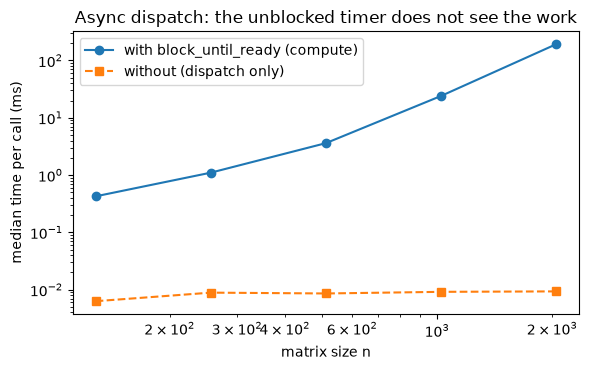

In [24]:
def time_unblocked(f, x, repeats=5):
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(x)                              # enqueue only
        ts.append(time.perf_counter() - t0)
    jax.block_until_ready(f(x))           # drain the queue before the next measurement
    return float(np.median(ts))

sizes = [128, 256, 512, 1024, 2048]
rows = []
for n in sizes:
    Mn = jnp.array(rng.normal(size=(n, n)), dtype=jnp.float32)
    t_b = bench(heavy, Mn)                # warms up (compiles for this shape) + blocks
    t_nb = time_unblocked(heavy, Mn)
    rows.append((n, t_nb, t_b))

print(f"{'n':>6}  {'unblocked (ms)':>15}  {'blocked (ms)':>13}  {'lie factor':>11}")
print("-" * 52)
for n, t_nb, t_b in rows:
    print(f"{n:>6}  {t_nb * 1e3:>15.3f}  {t_b * 1e3:>13.3f}  {t_b / t_nb:>10.0f}x")
print(f"\ndevice: {jax.devices()[0].device_kind}")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.loglog(sizes, [r[2] * 1e3 for r in rows], "o-", label="with block_until_ready (compute)")
ax.loglog(sizes, [r[1] * 1e3 for r in rows], "s--", label="without (dispatch only)")
ax.set_xlabel("matrix size n")
ax.set_ylabel("median time per call (ms)")
ax.set_title("Async dispatch: the unblocked timer does not see the work")
ax.legend()
fig.tight_layout()

> **Observe:** the blocked curve climbs steeply with $n$ (the slope approaches 3 on the
> log-log plot once the matmuls dominate), while the unblocked curve stays roughly flat —
> tens of microseconds, whatever the size. So the "lie factor" is not a fixed correction
> you could divide out: it **grows with the workload**. The bigger and more important the
> computation you are benchmarking, the more an unblocked timer flatters it. These are CPU
> numbers; on a GPU the blocked curve shifts down but the unblocked one stays put, so the
> lie gets worse, not better.


> **Observe:** the unblocked measurement is faster by a large factor — and the factor is
> not a property of the computation, it is a property of the queue. Two corollaries worth
> internalizing. First, any benchmark comparing two JAX implementations without blocking
> is measuring Python, and its conclusion is arbitrary. Second, async dispatch is why a
> `float(loss)` inside your training loop is expensive out of proportion to its size: it
> is a **synchronization point**, and it stalls the pipeline until the device catches up.
> Week 3's loop called `float(loss)` every step. Section 8 stops doing that.


---

## 7. Cost analysis: from wall-clock to FLOP/s

Wall-clock alone cannot tell you whether a kernel is good. 12 ms is fast if the work is
100 GFLOP and catastrophic if it is 1 MFLOP. To judge, you need the numerator: **how much
work did XLA actually decide to do?**

You do not have to estimate it. The compiled executable will tell you:

- `compiled.cost_analysis()` → FLOP count and bytes accessed for the program,
- `compiled.memory_analysis()` → argument, output, and temporary buffer sizes.

With FLOPs and bytes you get the two numbers Week 1's roofline model runs on:

$$\text{achieved FLOP/s} = \frac{\text{FLOPs}}{t}, \qquad
\text{arithmetic intensity } I = \frac{\text{FLOPs}}{\text{bytes accessed}}$$

Arithmetic intensity is the question "how much math do I get per byte I move?" Low $I$
means memory-bound: you are waiting on the bus and a faster ALU will not help you. High
$I$ means compute-bound: the kernel is doing real work and only more FLOP/s will move it.
That distinction decides everything downstream — it is why Week 6 does activation
checkpointing (recompute cheaply rather than move memory) and why Week 10 compresses
gradients (the wire is the slowest bus in the building).


In [25]:
def analyze(f, *args, repeats=5):
    lowered = jax.jit(f).lower(*args)
    compiled = lowered.compile()
    ca = compiled.cost_analysis()
    if isinstance(ca, (list, tuple)):
        ca = ca[0]
    flops = float(ca.get("flops", float("nan")))
    bytes_acc = float(ca.get("bytes accessed", float("nan")))
    t = bench(jax.jit(f), *args, repeats=repeats)
    return flops, bytes_acc, t


sizes = [128, 256, 512, 1024]
print(f"{'matmul N':>9}  {'GFLOP':>8}  {'MB moved':>9}  {'time (ms)':>10}  "
      f"{'GFLOP/s':>9}  {'intensity':>10}")
print("-" * 66)
mm_rows = []
for n in sizes:
    A = jnp.array(rng.normal(size=(n, n)), dtype=jnp.float32)
    flops, byts, t = analyze(lambda x: x @ x, A)
    mm_rows.append((n, flops, byts, t))
    print(f"{n:>9}  {flops / 1e9:>8.3f}  {byts / 1e6:>9.2f}  {t * 1e3:>10.3f}  "
          f"{flops / t / 1e9:>9.1f}  {flops / byts:>10.1f}")

print(f"\ntheoretical FLOPs for an N x N matmul: 2 N^3")
for n, flops, _, _ in mm_rows:
    print(f"   N={n:>5}: XLA reports {flops:>14,.0f}   2N^3 = {2 * n ** 3:>14,.0f}   "
          f"ratio {flops / (2 * n ** 3):.2f}")
print(f"\ndevice: {jax.devices()[0].device_kind}")

 matmul N     GFLOP   MB moved   time (ms)    GFLOP/s   intensity
------------------------------------------------------------------
      128     0.004       0.13       0.079       53.4        32.0
      256     0.034       0.52       0.184      182.8        64.0
      512     0.268       2.10       0.606      442.7       128.0
     1024     2.147       8.39       4.532      473.8       256.0

theoretical FLOPs for an N x N matmul: 2 N^3
   N=  128: XLA reports      4,194,304   2N^3 =      4,194,304   ratio 1.00
   N=  256: XLA reports     33,554,432   2N^3 =     33,554,432   ratio 1.00
   N=  512: XLA reports    268,435,456   2N^3 =    268,435,456   ratio 1.00
   N= 1024: XLA reports  2,147,483,648   2N^3 =  2,147,483,648   ratio 1.00

device: cpu


> **Observe:** XLA's reported FLOP count lands right on the textbook $2N^3$ — the cost
> analysis is not a heuristic, it is a count of the operations in the compiled program.
> That gives us a number we can *divide by time*, and now GFLOP/s is a claim we can
> defend. Notice also that arithmetic intensity grows with $N$: a matmul moves $O(N^2)$
> bytes to do $O(N^3)$ math, so $I \propto N$. Small matmuls are memory-bound, big ones
> are compute-bound. That single fact is why batching helps at all — and why, on the GPU
> node, it helps far more than it does here.


### Memory analysis, and where the model actually sits

`memory_analysis()` reports the buffers the executable needs: arguments, outputs, and
**temporaries** — the intermediates XLA allocates for you. That last number is the one
that OOMs your GPU node at 3 a.m., and it is the number Week 6 spends the whole session
attacking with `jax.remat`.


In [26]:
def mem_report(label, f, *args):
    c = jax.jit(f).lower(*args).compile()
    m = c.memory_analysis()
    print(f"{label:>26}  args {m.argument_size_in_bytes / 1e6:>7.2f} MB   "
          f"out {m.output_size_in_bytes / 1e6:>7.2f} MB   "
          f"temp {m.temp_size_in_bytes / 1e6:>7.2f} MB")
    return m


A = jnp.array(rng.normal(size=(1024, 1024)), dtype=jnp.float32)
print(f"{'program':>26}  {'buffers'}")
print("-" * 76)
mem_report("x @ x", lambda x: x @ x, A)
mem_report("6 chained matmuls", heavy, A)
mem_report("grad of sum(6 matmuls)", jax.grad(lambda x: jnp.sum(heavy(x))), A)

print()
print("The gradient needs SEVERAL times the temporary memory of the forward pass:")
print("reverse-mode AD must keep the forward intermediates alive until the backward")
print("pass consumes them. That is the Week 2 cost model showing up as bytes --")
print("and it is exactly what activation checkpointing (Week 6) trades away.")

                   program  buffers
----------------------------------------------------------------------------
                     x @ x  args    4.19 MB   out    4.19 MB   temp    0.00 MB
         6 chained matmuls  args    4.19 MB   out    4.19 MB   temp    4.19 MB


    grad of sum(6 matmuls)  args    4.19 MB   out    4.19 MB   temp   50.33 MB

The gradient needs SEVERAL times the temporary memory of the forward pass:
reverse-mode AD must keep the forward intermediates alive until the backward
pass consumes them. That is the Week 2 cost model showing up as bytes --
and it is exactly what activation checkpointing (Week 6) trades away.


### `jax.profiler`: the trace

For anything beyond a single kernel, the profiler collects a device trace you open in
TensorBoard or [Perfetto](https://ui.perfetto.dev). We cannot open a UI in this notebook,
but we can produce the trace and confirm it exists — the workflow you will use on the
GPU node, where the question "which op is eating my step time?" stops having an obvious
answer.


In [27]:
with tempfile.TemporaryDirectory() as trace_dir:
    with jax.profiler.trace(trace_dir):
        for _ in range(3):
            jax.block_until_ready(heavy(A))

    files = [f for f in glob.glob(os.path.join(trace_dir, "**", "*"), recursive=True)
             if os.path.isfile(f)]
    kinds = sorted({k for f in files for k in (".xplane.pb", ".trace.json.gz")
                    if os.path.basename(f).endswith(k)})
    total = sum(os.path.getsize(f) for f in files)
    print(f"trace written: {len(files)} files, {total / 1e3:.0f} KB total")
    for k in kinds:
        print(f"   {k}")
    print("\n  .xplane.pb     -> the raw device trace (TensorBoard / xprof reads this)")
    print("  .trace.json.gz -> Chrome trace format (drag into ui.perfetto.dev)")

print("\nOn the GPU node:")
print("  1.  with jax.profiler.trace('/tmp/tb'): <run ~10 steps>")
print("  2.  tensorboard --logdir /tmp/tb        (needs tensorboard-plugin-profile)")
print("  3.  read the op-level timeline: which fusion dominates? is the device idle")
print("      between steps (input pipeline bound)? how long is the all-reduce (Week 5)?")
print()
print("Also useful, and available right here:")
prof = jax.profiler.device_memory_profile()
print(f"  jax.profiler.device_memory_profile() -> {len(prof)} bytes of pprof data")
print("  (feed to `pprof` for a live allocation breakdown by source line)")

trace written: 2 files, 18430 KB total
   .trace.json.gz
   .xplane.pb

  .xplane.pb     -> the raw device trace (TensorBoard / xprof reads this)
  .trace.json.gz -> Chrome trace format (drag into ui.perfetto.dev)

On the GPU node:
  1.  with jax.profiler.trace('/tmp/tb'): <run ~10 steps>
  2.  tensorboard --logdir /tmp/tb        (needs tensorboard-plugin-profile)
  3.  read the op-level timeline: which fusion dominates? is the device idle
      between steps (input pipeline bound)? how long is the all-reduce (Week 5)?

Also useful, and available right here:
  jax.profiler.device_memory_profile() -> 11489 bytes of pprof data
  (feed to `pprof` for a live allocation breakdown by source line)


---

## 8. Lab 3: optimizing the Stage 1 training loop

Time to spend everything at once. We rebuild Week 3's Equinox ResNet and its training
loop exactly as it was, then apply today's tools one at a time and measure each. The
deliverable for Lab 3 is precisely this: a table of *what you changed* and *what it
bought*, in examples/sec, with the device named — **including the changes that bought
nothing**, which are the ones a report is tempted to quietly drop.

Four things look wrong with the Week 3 loop, and none of them are the model:

1. **Host indexing.** `X_tr[idx]` with a NumPy `idx` slices on the host and ships a fresh
   batch to the device every step.
2. **A synchronization point per step.** `float(loss)` blocks until the device drains.
   Python and the device take turns instead of overlapping.
3. **One dispatch per step.** Every step pays the fixed Python + dispatch overhead.
   `scan` would pay it once per *epoch*.
4. **No buffer donation.** The parameters are copied every step instead of being updated
   in place, even though the old ones are dead the moment the new ones exist.

Those are four **hypotheses**, not four facts. We will apply each one and measure it, and
the same math must come out the other side — we assert the loss curves match.

Say the quiet part first, because it is the actual lesson of Lab 3: **one of these four
is going to make things dramatically worse on this machine.** Not because the idea is
wrong, but because a real backend is a real thing with its own behaviour, and the only
way to know is to measure. If you would rather find out for yourself, guess which one
before you scroll.


In [28]:
# ---- Week 3's baseline codebase, verbatim ----
class ResBlock(eqx.Module):
    conv1: eqx.nn.Conv2d
    bn1: eqx.nn.BatchNorm
    conv2: eqx.nn.Conv2d
    bn2: eqx.nn.BatchNorm

    def __init__(self, channels, key, bn_momentum=0.9):
        k1, k2 = jax.random.split(key)
        self.conv1 = eqx.nn.Conv2d(channels, channels, 3, padding=1, use_bias=False, key=k1)
        self.bn1 = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch", momentum=bn_momentum)
        self.conv2 = eqx.nn.Conv2d(channels, channels, 3, padding=1, use_bias=False, key=k2)
        self.bn2 = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch", momentum=bn_momentum)

    def __call__(self, x, state):
        h, state = self.bn1(self.conv1(x), state)
        h = jax.nn.relu(h)
        h, state = self.bn2(self.conv2(h), state)
        return jax.nn.relu(x + h), state


class ResNet(eqx.Module):
    stem: eqx.nn.Conv2d
    stem_bn: eqx.nn.BatchNorm
    blocks: list
    head: eqx.nn.Linear

    def __init__(self, key, channels=16, n_blocks=2, n_classes=4, bn_momentum=0.9):
        ks = jax.random.split(key, n_blocks + 2)
        self.stem = eqx.nn.Conv2d(3, channels, 3, stride=2, padding=1, use_bias=False, key=ks[0])
        self.stem_bn = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch", momentum=bn_momentum)
        self.blocks = [ResBlock(channels, ks[i + 1], bn_momentum) for i in range(n_blocks)]
        self.head = eqx.nn.Linear(channels, n_classes, key=ks[-1])

    def __call__(self, x, state):
        x, state = self.stem_bn(self.stem(x), state)
        x = jax.nn.relu(x)
        for block in self.blocks:
            x, state = block(x, state)
        x = jnp.mean(x, axis=(1, 2))
        return self.head(x), state


def batched_forward(model, state, x):
    def forward_one(m, s, xi):
        return m(xi, s)
    return eqx.filter_vmap(forward_one, in_axes=(None, None, 0), out_axes=(0, None),
                           axis_name="batch")(model, state, x)


def loss_fn(model, state, x, y):
    logits, state = batched_forward(model, state, x)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean(), state


# ---- Week 3's synthetic CIFAR-shaped data (the harness has no network) ----
N_CLASSES, IMG = 4, 32

def make_templates(key, n_classes=N_CLASSES, size=IMG):
    lo = jax.random.normal(key, (n_classes, 3, 8, 8))
    return jax.image.resize(lo, (n_classes, 3, size, size), method="linear")

def make_data(n, key, templates, noise=1.0):
    k_lab, k_noise = jax.random.split(key)
    labels = jax.random.randint(k_lab, (n,), 0, templates.shape[0])
    noise_arr = jax.random.normal(k_noise, (n,) + templates.shape[1:]) * noise
    return templates[labels] + noise_arr, labels

TEMPLATES = make_templates(jax.random.key(7))
X_tr, Y_tr = make_data(2048, jax.random.key(1), TEMPLATES)

BATCH = 128
STEPS_PER_EPOCH = len(X_tr) // BATCH
optimizer = optax.sgd(1e-2, momentum=0.9)

model0, bn0 = eqx.nn.make_with_state(ResNet)(jax.random.key(1))
opt0 = optimizer.init(eqx.filter(model0, eqx.is_inexact_array))

n_params = sum(p.size for p in jax.tree.leaves(eqx.filter(model0, eqx.is_inexact_array)))
print(f"model: {n_params:,} parameters | data: {X_tr.shape} | batch {BATCH} "
      f"-> {STEPS_PER_EPOCH} steps/epoch")
print(f"device: {jax.devices()[0].device_kind}")

model: 9,876 parameters | data: (2048, 3, 32, 32) | batch 128 -> 16 steps/epoch
device: cpu


### v0 — the Week 3 loop, as written

Host indexing, `float(loss)` every step, one dispatch per step, no donation. This is the
honest baseline: not a strawman, just last week's code.


In [29]:
@eqx.filter_jit
def train_step(model, state, opt_state, x, y):
    (loss, state), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, state, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    return eqx.apply_updates(model, updates), state, opt_state, loss


def run_v0(epochs=3):
    m, s, o = model0, bn0, opt0
    Xh, Yh = np.asarray(X_tr), np.asarray(Y_tr)      # host arrays, as in Week 3
    losses = []
    # warm up / compile
    jax.block_until_ready(train_step(m, s, o, X_tr[:BATCH], Y_tr[:BATCH])[3])

    t0 = time.perf_counter()
    for e in range(epochs):
        perm = np.asarray(jax.random.permutation(jax.random.fold_in(jax.random.key(123), e), len(Xh)))
        for i in range(STEPS_PER_EPOCH):
            idx = perm[i * BATCH:(i + 1) * BATCH]
            m, s, o, l = train_step(m, s, o, Xh[idx], Yh[idx])   # host slice -> transfer
            losses.append(float(l))                              # SYNC every step
    dt = time.perf_counter() - t0
    return dt, losses, (m, s, o)


EPOCHS = 3
t_v0, loss_v0, _ = run_v0(EPOCHS)
steps = EPOCHS * STEPS_PER_EPOCH
print(f"v0 baseline (Week 3 as written)")
print(f"   {steps} steps in {t_v0:.3f} s -> {steps * BATCH / t_v0:,.0f} examples/sec")
print(f"   final loss {np.mean(loss_v0[-8:]):.4f}")

v0 baseline (Week 3 as written)
   48 steps in 1.417 s -> 4,336 examples/sec
   final loss 0.4036


### v1 — keep the data on the device, stop synchronizing

Two fixes, both about the *boundary* rather than the math. Put the whole dataset on the
device once and index it with a `jnp` array (the gather runs on the device). And stop
calling `float(loss)` — accumulate the loss arrays in a list and convert them **after**
the loop, in one shot.


In [30]:
def run_v1(epochs=EPOCHS):
    m, s, o = model0, bn0, opt0
    losses = []
    jax.block_until_ready(train_step(m, s, o, X_tr[:BATCH], Y_tr[:BATCH])[3])

    t0 = time.perf_counter()
    for e in range(epochs):
        perm = jax.random.permutation(jax.random.fold_in(jax.random.key(123), e), len(X_tr))
        for i in range(STEPS_PER_EPOCH):
            idx = jax.lax.dynamic_slice(perm, (i * BATCH,), (BATCH,))   # device-side
            m, s, o, l = train_step(m, s, o, X_tr[idx], Y_tr[idx])
            losses.append(l)                       # keep it as a device array: NO sync
    jax.block_until_ready(losses[-1])              # sync ONCE, at the end
    dt = time.perf_counter() - t0
    return dt, [float(x) for x in losses], (m, s, o)


t_v1, loss_v1, _ = run_v1()
print(f"v1 device data + no per-step sync")
print(f"   {steps} steps in {t_v1:.3f} s -> {steps * BATCH / t_v1:,.0f} examples/sec"
      f"   ({t_v0 / t_v1:.2f}x vs v0)")
print(f"   final loss {np.mean(loss_v1[-8:]):.4f}")

v1 device data + no per-step sync
   48 steps in 1.514 s -> 4,059 examples/sec   (0.94x vs v0)
   final loss 0.4036


### v2 — `scan` the epoch

Now the loop itself. One `scan` per epoch means **one dispatch per epoch** instead of
sixteen, and the per-step Python overhead disappears entirely.

The mechanics are the Week 3 contract, unchanged: the carry is `(params, bn_state,
opt_state)` — three of our four states — and the PRNG (the fourth) is handled outside,
by folding in the epoch. `eqx.partition` splits the model into traced arrays and static
structure, so the carry holds only arrays and its treedef is stable across iterations,
which is exactly what `scan` demands.


In [31]:
params0, static0 = eqx.partition(model0, eqx.is_inexact_array)


def scan_step(carry, batch):
    params, bn_state, opt_state = carry
    x, y = batch
    model = eqx.combine(params, static0)

    def _loss(p, s):
        return loss_fn(eqx.combine(p, static0), s, x, y)

    (loss, bn_state), grads = jax.value_and_grad(_loss, has_aux=True)(params, bn_state)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    return (params, bn_state, opt_state), loss


@jax.jit
def run_epoch(params, bn_state, opt_state, xs, ys):
    # xs: (steps, BATCH, 3, 32, 32) -- the whole epoch, pre-batched
    return jax.lax.scan(scan_step, (params, bn_state, opt_state), (xs, ys))


def epoch_batches(e):
    perm = jax.random.permutation(jax.random.fold_in(jax.random.key(123), e), len(X_tr))
    idx = perm[:STEPS_PER_EPOCH * BATCH].reshape(STEPS_PER_EPOCH, BATCH)
    return X_tr[idx], Y_tr[idx]


def run_v2(epochs=EPOCHS):
    p, s, o = params0, bn0, opt0
    xs, ys = epoch_batches(0)
    jax.block_until_ready(run_epoch(p, s, o, xs, ys)[1])      # warm up (compile the scan)

    losses = []
    t0 = time.perf_counter()
    for e in range(epochs):
        xs, ys = epoch_batches(e)
        (p, s, o), ls = run_epoch(p, s, o, xs, ys)            # ONE dispatch per epoch
        losses.append(ls)
    jax.block_until_ready(losses[-1])
    dt = time.perf_counter() - t0
    return dt, np.concatenate([np.asarray(l) for l in losses]), (p, s, o)


t_v2, loss_v2, _ = run_v2()
print(f"v2 scan over the epoch")
print(f"   {steps} steps in {t_v2:.3f} s -> {steps * BATCH / t_v2:,.0f} examples/sec"
      f"   ({t_v0 / t_v2:.2f}x vs v0)")
print(f"   final loss {np.mean(loss_v2[-8:]):.4f}")
print(f"\n   dispatches: v0/v1 = {steps} (one per step), v2 = {EPOCHS} (one per epoch)")
print("\n   ...that is not a typo. Read the speedup again.")

v2 scan over the epoch
   48 steps in 14.072 s -> 437 examples/sec   (0.10x vs v0)
   final loss 0.4036

   dispatches: v0/v1 = 48 (one per step), v2 = 3 (one per epoch)

   ...that is not a typo. Read the speedup again.


### The `scan` result is a disaster. Diagnose it.

`scan` fixed everything the theory said to fix — 3 dispatches instead of 48, no Python
in the loop, identical loss — and it made the training loop **an order of magnitude
slower**. Do not explain that away, and do not delete it from the report. Explain it.

The temptation is to conclude "`scan` is slow", but Section 4 measured `scan` on a
matmul-flavoured step and it was *fine* — comparable run time, dramatically better
compile time. So the variable that changed is not `scan`. It is **what is inside** it.

Here is the hypothesis worth testing: `scan` lowers to an XLA **while loop**, and a while
loop is an optimization barrier. XLA cannot fuse across iterations, and — the part that
matters here — the CPU backend's fast, thread-parallel convolution path does not apply
inside a loop body. A matmul-shaped step would not care much. A convolution-shaped step
would fall off a cliff.

That is a testable claim: **the same step, once dense and once convolutional, scanned
versus looped.** If the hypothesis is right, dense is unaffected and conv collapses.


In [32]:
def scan_vs_loop(step_fn, carry0, xs, label):
    f_scan = jax.jit(lambda c, x: jax.lax.scan(step_fn, c, x))
    f_one = jax.jit(step_fn)
    t_scan = bench(f_scan, carry0, xs, repeats=3)

    def looped(c, x):
        for i in range(x.shape[0]):
            c, _ = f_one(c, x[i])
        return c
    t_loop = bench(looped, carry0, xs, repeats=3)
    print(f"{label:>28}  scan {t_scan * 1e3:>8.1f} ms   loop {t_loop * 1e3:>8.1f} ms   "
          f"scan/loop {t_scan / t_loop:>6.2f}x")
    return t_scan / t_loop


T_MB = 16
print("the same experiment, twice: a DENSE step and a CONVOLUTIONAL step")
print("-" * 92)

# --- dense: a matmul-shaped training step
Dm = 512
Wm = jax.random.normal(jax.random.key(0), (Dm, Dm)) / np.sqrt(Dm)
Xm = jax.random.normal(jax.random.key(1), (T_MB, 128, Dm))
def dense_step(w, x):
    g = jax.grad(lambda w: jnp.sum(jnp.tanh(x @ w) ** 2))(w)
    return w - 1e-4 * g, jnp.sum(g ** 2)
r_dense = scan_vs_loop(dense_step, Wm, Xm, "dense (matmul) step")

# --- conv: a convolution-shaped training step
Kc = jax.random.normal(jax.random.key(0), (16, 3, 3, 3)) * 0.1
Xc = jax.random.normal(jax.random.key(1), (T_MB, 128, 3, 32, 32))
def conv_step(k, x):
    def f(k):
        out = jax.lax.conv_general_dilated(x, k, (1, 1), "SAME",
                                           dimension_numbers=("NCHW", "OIHW", "NCHW"))
        return jnp.sum(out ** 2)
    g = jax.grad(f)(k)
    return k - 1e-6 * g, jnp.sum(g ** 2)
r_conv = scan_vs_loop(conv_step, Kc, Xc, "convolutional step")

print("-" * 92)
print(f"\nhypothesis confirmed: dense is ~{r_dense:.2f}x (scan is fine, even a little "
      f"faster),")
print(f"                      conv is  ~{r_conv:.1f}x SLOWER inside the loop body.")
print(f"\ndevice: {jax.devices()[0].device_kind}  <- and that qualifier is the whole point")

the same experiment, twice: a DENSE step and a CONVOLUTIONAL step
--------------------------------------------------------------------------------------------


         dense (matmul) step  scan      9.5 ms   loop     10.6 ms   scan/loop   0.89x


          convolutional step  scan    761.9 ms   loop     88.2 ms   scan/loop   8.64x
--------------------------------------------------------------------------------------------

hypothesis confirmed: dense is ~0.89x (scan is fine, even a little faster),
                      conv is  ~8.6x SLOWER inside the loop body.

device: cpu  <- and that qualifier is the whole point


> **Observe:** the cause is isolated. It is not `scan`, and it is not our model: it is
> **convolutions inside a while-loop body on the XLA:CPU backend**, which lose the
> optimized, thread-parallel convolution path that the same op gets at the top level.
> Dense steps are unaffected — `scan` is marginally *faster* there.
>
> Three lessons, and the third is the one Lab 3 is really about.
>
> 1. **`scan`'s payoff is compile time, not run time.** Section 4 measured it exactly:
>    186× versus flat. Nobody promised it makes the step faster, and here it makes it
>    slower. Use it when the trip count varies or compile time hurts — which is precisely
>    Week 7, where $\tau \in \{1, 5, 20, 100\}$ local steps must not mean four growing
>    compiles.
> 2. **An optimization is a hypothesis about a specific machine.** "Fewer dispatches is
>    faster" is a good hypothesis. It was wrong here, for a reason that lives in the
>    backend's convolution implementation and appears in no tutorial. On the GPU node this
>    experiment can come out differently — which is why you rerun it there instead of
>    trusting this cell.
> 3. **The measurement is what makes this a lab.** Had we skipped it — as a plausible
>    "obviously fewer dispatches is better" refactor would — we would have shipped a 10×
>    regression and *called it an optimization* in the report. That is not a hypothetical
>    failure mode; it is the most common one in performance work.


### v3 — donate the buffers

So we drop `scan` for this step (keeping it in the toolbox for Week 7) and go back to the
per-step loop from v1, with the last fix on top.

Every step produces new parameters and the old ones die immediately, but XLA does not
know that: by default it must assume the caller still wants its inputs, so it allocates
fresh output buffers and copies. `donate_argnums` tells XLA *"these arguments are dead on
return — write the output on top of them."*

The promise is real and enforced: touching a donated array afterwards raises. That is a
feature (it catches the bug at the point of the mistake), but it means donation is only
correct in a loop where you genuinely rebind and never look back — which a training loop
does.


In [33]:
@functools.partial(jax.jit, donate_argnums=(0, 1, 2))
def train_step_donated(params, bn_state, opt_state, x, y):
    # identical math to train_step -- but params/bn_state/opt_state are dead on return
    def _loss(p, s):
        return loss_fn(eqx.combine(p, static0), s, x, y)
    (loss, bn_state), grads = jax.value_and_grad(_loss, has_aux=True)(params, bn_state)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    return params, bn_state, opt_state, loss


copy = lambda t: jax.tree.map(lambda a: a + 0, t)      # donation CONSUMES its inputs


def run_v3(epochs=EPOCHS):
    # warm up on copies -- otherwise the compile call would eat params0 itself
    jax.block_until_ready(train_step_donated(copy(params0), copy(bn0), copy(opt0),
                                             X_tr[:BATCH], Y_tr[:BATCH])[3])
    p, s, o = copy(params0), copy(bn0), copy(opt0)

    losses = []
    t0 = time.perf_counter()
    for e in range(epochs):
        perm = jax.random.permutation(jax.random.fold_in(jax.random.key(123), e), len(X_tr))
        for i in range(STEPS_PER_EPOCH):
            idx = jax.lax.dynamic_slice(perm, (i * BATCH,), (BATCH,))
            # p, s, o are CONSUMED here and immediately rebound -- never touched again
            p, s, o, l = train_step_donated(p, s, o, X_tr[idx], Y_tr[idx])
            losses.append(l)
    jax.block_until_ready(losses[-1])
    dt = time.perf_counter() - t0
    return dt, [float(x) for x in losses], (p, s, o)


t_v3, loss_v3, final = run_v3()
print(f"v3 = v1 + donated buffers (per-step loop; scan dropped after the v2 diagnosis)")
print(f"   {steps} steps in {t_v3:.3f} s -> {steps * BATCH / t_v3:,.0f} examples/sec"
      f"   ({t_v0 / t_v3:.2f}x vs v0)")
print(f"   final loss {np.mean(loss_v3[-8:]):.4f}")

# the donation promise is enforced -- show it
donated_fn = jax.jit(lambda a: a * 2, donate_argnums=0)
a = jnp.ones(4)
_ = jax.block_until_ready(donated_fn(a))
try:
    print(jnp.sum(a))
    print("\n   no error?! (donation was declined -- see the note below)")
except Exception as e:
    print("\n   touching a donated array afterwards ->", type(e).__name__)
    print("   ", str(e).split(chr(10))[0][:88])
    print("   ^ the donation contract is ENFORCED, not advisory. This is a good error:")
    print("     it fires at the mistake, not three steps later with wrong numbers.")

v3 = v1 + donated buffers (per-step loop; scan dropped after the v2 diagnosis)
   48 steps in 1.461 s -> 4,206 examples/sec   (0.97x vs v0)
   final loss 0.4036

   touching a donated array afterwards -> RuntimeError
    Array has been deleted with shape=float32[4].
   ^ the donation contract is ENFORCED, not advisory. This is a good error:
     it fires at the mistake, not three steps later with wrong numbers.


### Same math? Prove it.

An optimization that changes the answer is not an optimization. All four versions ran the
same model on the same batches in the same order with the same seed, so their loss curves
must agree to floating-point noise. Check before believing any of the numbers above.


           version   final loss   max |diff| vs v0
----------------------------------------------------
       v0 baseline      0.40362           0.00e+00
  v1 device+nosync      0.40362           0.00e+00
           v2 scan      0.40362           4.20e-06
      v3 v1+donate      0.40362           0.00e+00

^ differences at the 1e-6 level are XLA reassociating float adds, not a bug.

           version   time (s)   examples/sec   speedup
------------------------------------------------------
       v0 baseline      1.417          4,336     1.00x
  v1 device+nosync      1.514          4,059     0.94x
           v2 scan     14.072            437     0.10x
      v3 v1+donate      1.461          4,206     0.97x

device: cpu  |  this is the Lab 3 deliverable table.


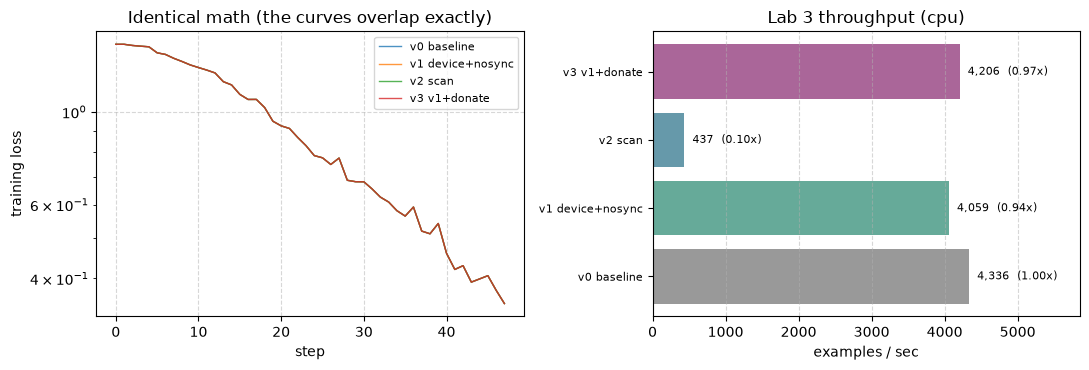

In [34]:
curves = {"v0 baseline": loss_v0, "v1 device+nosync": loss_v1,
          "v2 scan": loss_v2, "v3 v1+donate": loss_v3}

print(f"{'version':>18}  {'final loss':>11}  {'max |diff| vs v0':>17}")
print("-" * 52)
for name, c in curves.items():
    d = float(np.max(np.abs(np.asarray(c) - np.asarray(loss_v0))))
    print(f"{name:>18}  {np.mean(c[-8:]):>11.5f}  {d:>17.2e}")
print("\n^ differences at the 1e-6 level are XLA reassociating float adds, not a bug.")

times = {"v0 baseline": t_v0, "v1 device+nosync": t_v1, "v2 scan": t_v2, "v3 v1+donate": t_v3}
rates = {k: steps * BATCH / v for k, v in times.items()}

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

for name, c in curves.items():
    ax[0].semilogy(c, lw=1, alpha=0.8, label=name)
ax[0].set_xlabel("step"); ax[0].set_ylabel("training loss")
ax[0].set_title("Identical math (the curves overlap exactly)")
ax[0].legend(fontsize=8); ax[0].grid(True, ls="--", alpha=0.5)

names = list(rates)
ax[1].barh(range(len(names)), [rates[n] for n in names], color=["#999", "#6a9", "#69a", "#a69"])
ax[1].set_yticks(range(len(names))); ax[1].set_yticklabels(names, fontsize=8)
ax[1].set_xlabel("examples / sec")
ax[1].set_title(f"Lab 3 throughput ({jax.devices()[0].device_kind})")
ax[1].grid(True, ls="--", alpha=0.5, axis="x")
for i, n in enumerate(names):
    ax[1].text(rates[n], i, f"  {rates[n]:,.0f}  ({t_v0 / times[n]:.2f}x)", va="center", fontsize=8)
ax[1].set_xlim(0, max(rates.values()) * 1.35)

plt.tight_layout()

print(f"\n{'version':>18}  {'time (s)':>9}  {'examples/sec':>13}  {'speedup':>8}")
print("-" * 54)
for n in names:
    print(f"{n:>18}  {times[n]:>9.3f}  {rates[n]:>13,.0f}  {t_v0 / times[n]:>7.2f}x")
print(f"\ndevice: {jax.devices()[0].device_kind}  |  this is the Lab 3 deliverable table.")

> **Observe:** this is the Lab 3 deliverable, and the honest reading of it is more
> useful than a triumphant one would have been.
>
> **The math never moved.** All four curves agree to ~1e-6 (XLA reassociating float
> additions), so every difference in the table is machinery, not modelling. Establish
> that *first*; a speedup that changes your loss curve is a bug wearing a costume.
>
> **Not one of the four hypotheses paid off on this machine.** Three came out slightly
> *negative* and one was a catastrophe. Read that as a result, not an embarrassment —
> take the reasons one at a time:
>
> - **v1 (device data, no per-step sync)** comes in a few percent **slower** than v0, and
>   reproducibly so. The theory is sound; it just does not apply *here*. Our "device" is
>   the same CPU the host runs on, so "shipping a batch to the device" was already a
>   memcpy inside one RAM, and the async queue that `float(loss)` drains is barely a
>   queue — Section 6 measured dispatch in microseconds against a step of milliseconds.
>   There was nothing to win, and we *added* work: `dynamic_slice` plus a device-side
>   gather per step, where NumPy's host slice of an in-RAM array was nearly free. An
>   optimization aimed at a cost you are not paying is just overhead.
> - **v2 (`scan`)** cost an order of magnitude, for the backend-specific reason isolated
>   above. Kept in the table on purpose: a report that shows only what worked is a report
>   nobody should trust.
> - **v3 (donation)** is likewise a small loss. Donation saves a *copy* of the parameters,
>   and our parameters are ~10k floats — about 40 KB. Eliminating a 40 KB memcpy per step
>   is unmeasurable, while the aliasing bookkeeping is not quite free.
>
> **So is the lab a failure?** No — it is a correctly executed measurement of a machine
> where these overheads are not the bottleneck, and knowing *that* is the deliverable.
> (The reflex to fix here is the one that says *"my optimization must have helped, the
> benchmark is noisy"* and reruns until a favourable number appears. The 0.9× is
> reproducible. Believe it.)
> Every one of these fixes targets **host-side cost per step**, and host-side cost is
> only worth attacking when it is a meaningful fraction of the step. On this CPU, a batch
> of 128 through a ResNet takes long enough that a few hundred microseconds of Python
> vanishes into it.
>
> **That fraction is exactly what inverts on the GPU node.** The device step gets 10–100×
> faster; the Python, the dispatch, the host-to-device transfer, and the parameter copy
> do **not** — they are host work, and your CPU is the same CPU. A cost that is 2% of the
> budget here can be 40% there. Same diff, same code, different verdict. That is the
> general law worth carrying out of Lab 3: **the faster your device, the more your host
> costs you** — and it is why the interesting version of this table is the one *you*
> produce on real hardware, not the one printed above. Donation follows the same rule
> from the other side: at $10^8$ parameters that copy is the difference between fitting
> in memory and not, and it stops being an optimization and becomes a requirement. Which
> is Week 6.


---

## Summary

Stage 1 is finished. The codebase is correct (Week 3) and now it is fast, and — more
importantly — every claim about it is measured.

- **`vmap` is the batch axis.** Write the model for one example; let the transformation
  add the axis. It costs nothing (we matched a hand-written batched matmul to within
  noise) and it generalizes: batching over examples, over models, and — in Week 12 — over
  **per-example gradients**, which is DP-SGD's entire mechanism, obtained for free.
- **PyTrees are leaves + treedef.** Leaves are traced; the treedef is a compile-time
  constant and part of the `jit` cache key. Put something that changes per step in the
  static half and you recompile every step. `ravel_pytree` turns any model into the
  vector that Week 10's compression and Week 13's norm filters operate on.
- **PRNG state is threaded, not consulted.** Reusing a key silently repeats your
  randomness. `split` when you need $n$ streams now; `fold_in` when you can name the
  consumer — but never both on one parent key, since `split(k, n)[i]` *is*
  `fold_in(k, i)`; give each consumer its own child key first. `fold_in` is how 100
  clients get independent, reproducible, coordination-free streams in Week 9.
- **`scan` gives the loop to the compiler — and that is a compile-time win, not a
  run-time one.** The unrolled loop's compile time tracked $\propto T$ over a 64× sweep;
  `scan`'s was flat. But in Lab 3 the same `scan` made the real training step **~10×
  slower**, and we tracked the cause down to convolutions inside an XLA:CPU while-loop
  body losing their fast path. Reach for `scan` when the trip count varies or compile
  time hurts (Week 7's $\tau$ sweep), not as a reflex.
- **The `jit` cache key is shape + dtype + treedef + static args.** Everything else is
  traced. The dangerous case is the one that is *not* in the key: a Python scalar in a
  closure is baked in at trace time, so changing your learning rate afterwards changes
  nothing and warns you about nothing. If it can change, it is an argument.
- **Dispatch is async.** We over-reported speed by a large factor by forgetting
  `block_until_ready`, and that error grows with the size of the work. Every timing cell
  in this course blocks, repeats, takes a median, and names the device.
- **Cost analysis makes wall-clock meaningful.** XLA reported exactly $2N^3$ FLOPs for an
  $N\times N$ matmul, which turns milliseconds into GFLOP/s and bytes into arithmetic
  intensity — the Week 1 roofline, now measurable on your own step.
- **Lab 3 measured four plausible optimizations and reported what happened**: three came
  out a few percent *negative* on this CPU and one (`scan`) was a 10× regression — all
  with loss curves identical to 1e-6. Every one of them targets *host-side cost per step*, which on this
  machine is not the bottleneck. The finding is not "these do not work"; it is "these do
  not work **here**, and here is the number". On the GPU node the device step gets 10–100×
  faster while the host cost does not, so the same diff is worth measuring again — which
  is the assignment.

**The thread.** Everything today was single-device. The reason we care so much about
overhead per step is that Week 5 is about to add a new cost to every step — an
**AllReduce** — and you cannot see a communication bottleneck through a fog of Python
overhead you never removed. First you learn to measure one device honestly. Then you add
the second one and watch what breaks: Ring AllReduce moves $2(P-1)/P \cdot |g|$ bytes per
worker per step, and suddenly `ravel_pytree` and the size of your gradient are the
performance story. That is Stage 2.

### Further Exercises

1. **Find the knee that this CPU cannot show you.** Rerun Section 8's v3 on the GPU node
   at batch sizes $\{32, 64, \dots, 2048\}$ and plot examples/sec. Locate the saturation
   point, then report v0's speedup at batch 32 vs at batch 2048. Explain the trend using
   the host-overhead-vs-device-speed argument from the Observe cell.
2. **Per-example gradients on the real model.** `vmap` `eqx.filter_grad(loss)` over a
   batch of the Section 8 ResNet to get per-example gradients. Measure the memory
   (`memory_analysis`) and step time against the ordinary batch gradient. What is the
   multiplier? Now you know DP-SGD's price before Week 12 asks you to pay it.
3. **`scan` the local steps.** Rewrite `run_epoch` so the trip count $\tau$ is a
   *parameter*: `scan` over `xs[:tau]`. Time compilation for $\tau \in \{1, 5, 20, 100\}$
   and compare against an unrolled version. Then average the parameters of 4 independent
   copies after each $\tau$-block. You have built Week 7's Local SGD harness, and it
   compiles once.
4. **Hunt a recompile in the wild.** Set `JAX_LOG_COMPILES=1` (or
   `jax.config.update("jax_log_compiles", True)`) and rerun Section 8. Count the
   compilations for each version. Then deliberately introduce a ragged final batch and
   count again.
5. **Roofline your step.** Use `cost_analysis` on the v3 `run_epoch` to get FLOPs and
   bytes accessed, compute achieved GFLOP/s and arithmetic intensity, and place the point
   on a roofline for your device (look up its peak FLOP/s and memory bandwidth). Is the
   Stage 1 step compute-bound or memory-bound? Does the answer change with batch size —
   and does it change between CPU and GPU?
